## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 36.9 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
xarray 2025.3.1 requires pandas

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# import to split data
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

## Loading the dataset

In [3]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# The pandas read_csv method can be used to read the file into a dataframe.
path="/content/drive/MyDrive/AI-ML Course/Python Foundations/LoanModelling/Loan_Modelling.csv"
loan_model = pd.read_csv(path)

# creating a copy of the data
data = loan_model.copy()

## Data Overview

* Observations
* Sanity checks

In [5]:
# The head method shows us the first 5 rows of the data.
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [6]:
# Using shape attribute to get the number of rows and columns.
# The first attribute is the number of rows and second is the number of columns
data.shape

(5000, 14)

- *We observe that the data has 5000 rows and 14 columns.*

In [ ]:
# The info method gives us the datatypes of the columns
# as well as how many of them are null.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


- *We can see that 13 of the columns are integers.*
- *We see that 1 of the columns CCAvg is a float column.*

In [ ]:
# Checking for null values in columns  using isnull method and summing up for the columns.
print(data.isnull().sum())

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64


- *We can see that none of the columns have any null values.*

In [ ]:
# Checking for duplicates by excluding ID column
# as that column should be unique

# Column to exclude
exclude_column = 'ID'

# Create a subset of columns
subset_columns = [col for col in data.columns if col != exclude_column]

# Check for duplicates excluding the specified column
duplicates = data.duplicated(subset=subset_columns, keep=False)

duplicate_rows = data[duplicates]
print(duplicate_rows)

Empty DataFrame
Columns: [ID, Age, Experience, Income, ZIPCode, Family, CCAvg, Education, Mortgage, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard]
Index: []


- *There are no duplicates in the data.*

In [ ]:
# Using the describe function which will give a statistical summary of the data (including min, max, average, count and percentile values)
# for all the columns and then T for transposing the values
data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0



- *We see that the experience column seems to have negative values since the minimum value is -3.*
- *This cannot be correct as experience cannot be negative.*
- *Going to check how many values are negative.*

In [ ]:
# Checking count of negative values and percentage of negative values in experience column.
len(data[data['Experience'] < 0])

52


- *We see that 52 rows have value of Experience as negative.*
- *It could be safe to assume that the negative sign for these values could have been entered by mistake.*


In [ ]:
# Since we can assume that for the negative experience values the negative
# sign could have been entered by mistake, we can take the absolute value
# for the experience column and store that in the column to use for further analysis
data['Experience'] = abs(data['Experience'])

# Checking that there are no more negative experience values
print('Count of rows with experience as negative is:' ,len(data[data['Experience'] < 0]))

Count of rows with experience as negative is: 0


## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

#### **Defining some useful functions**

In [ ]:
# Defining some functions to create better plots
# below function shows the barplot with percentages
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot



In [ ]:
# Function for histogram and boxplot combined
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

### Univariate Analysis

#### **Observations on Age**

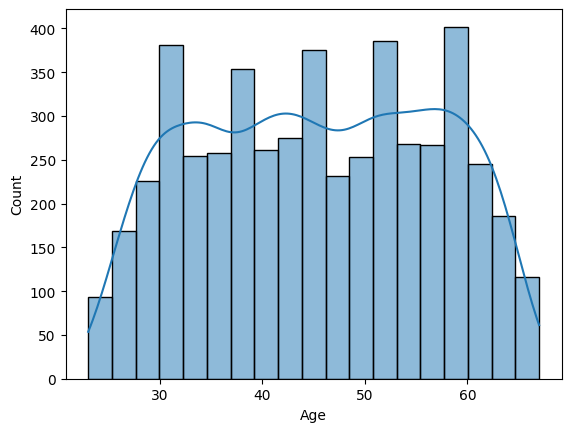

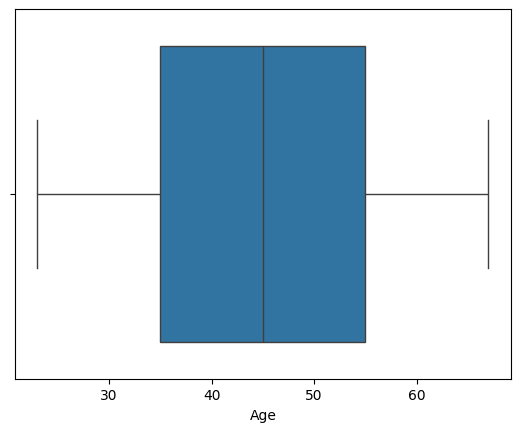

In [ ]:
# Doing univariate analysis on the Age column
# Doing a histplot to get an idea of the values in this column
#labeled_barplot(data,'Age', perc=True)
sns.histplot(data=data,x='Age', kde=True)
plt.show()
sns.boxplot(data=data,x='Age')
#histogram_boxplot(data, "Age", bins=50)
plt.show()


- *The data has a very good count of users between ages 30 and 60 which would give us insights into their financial decisions during their work life.*
- *We see that median age in the dataset is 45.*
- *50% of the customers have age less than 45 and 75% of them have age less than 55.*

#### **Observations on Mortgage**

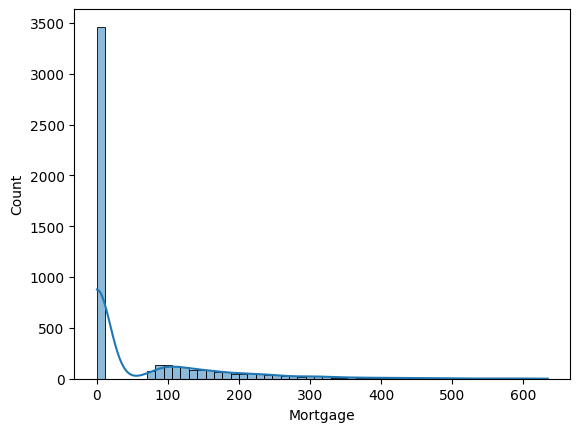

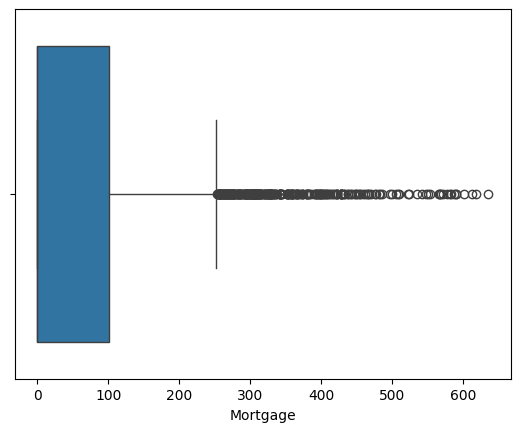

In [ ]:
# Doing univariate analysis on the Mortgage column
# Doing a histplot and boxplot to get an idea of the values in this column
sns.histplot(data=data,x='Mortgage', kde=True)
plt.show()
sns.boxplot(data=data,x='Mortgage')
#histogram_boxplot(data, "Age", bins=50)
plt.show()

- *We see that mortgage is highly right skewed with lots of outliers.*
- *We also see that more than 50% of customers have not taken a house mortgage or have 0 house mortgage.*
- *We also observe that 75% of customers have less than 100 thousand in house mortgage.*

In [ ]:
# Checking how many users have a mortgage using value_counts with normalize
# to get percentage data
data['Mortgage'].value_counts(normalize=True)

,proportion
Mortgage,
0,0.6924
98,0.0034
103,0.0032
89,0.0032
91,0.0032
...,...
550,0.0002
283,0.0002
612,0.0002



- *We see that a large number of the customers (69%) do not have a mortgage.*

In [ ]:
# Calculating the mean and median for Mortgage
print(f'Mean of Mortgage is {data["Mortgage"].mean()}')
print(f'Median of Mortgage is {data["Mortgage"].median()}')

Mean of Mortgage is 56.4988
Median of Mortgage is 0.0


#### **Observations on CreditCard**

<ipython-input-13-d1ac9fe6a02c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


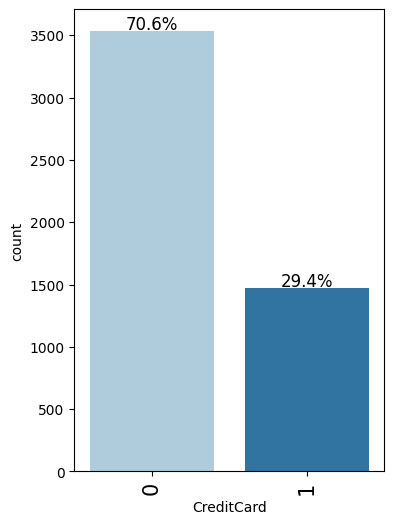

In [ ]:
# Doing univariate analysis on the CreditCard column
# Doing a barplot to get an idea of the values in this column
labeled_barplot(data,'CreditCard', perc=True);


- *We see that most of the users 70% do not have any outside creditcards.*
- *This seems to be the same percentage as those who do not have a mortgage which was 69 percent.*

In [ ]:
# Count of customers with No outside CreditCard
print(f'Count of customers with  outside CreditCard is {data["CreditCard"].value_counts()[1]}')

Count of customers with  outside CreditCard is 1470


#### **Observations on CCAvg**

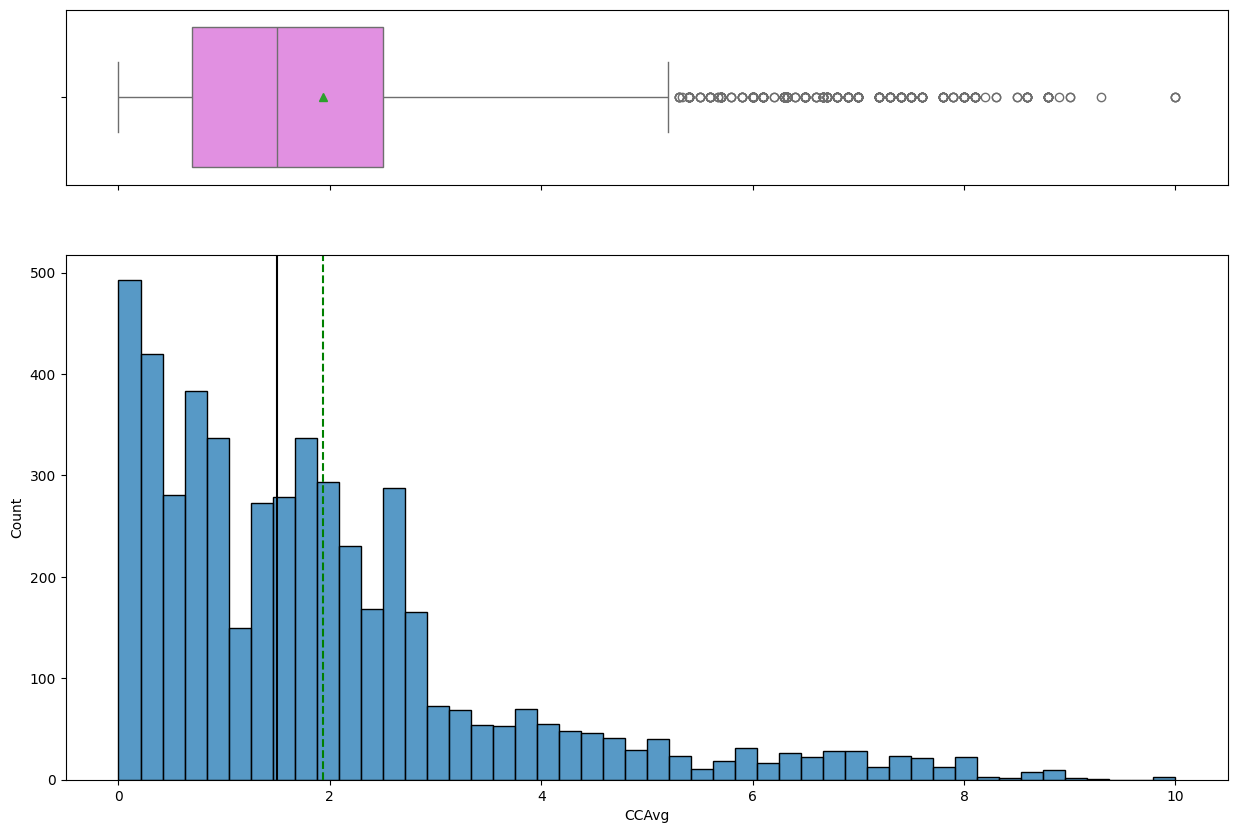

In [ ]:
# Doing univariate analysis on the CCAvg column
# Doing a histplot and boxplot to get an idea of the values in this column
histogram_boxplot(data,'CCAvg');


- *We also observe that 50% of the customers spend less than 1500 per month on credit cards.*
- *We also observe that 75% of the customers spend less than 2500 per month on credit cards.*
- *We see that this data point is highly right skewed with lot of outliers. This is to be expected as there would be some people who use credit for all their monthly spending.*

In [ ]:
# Checking percent of customers with 0 CCAvg
print(f'Percent of customers with 0 Credit card average is {data["CCAvg"].value_counts(normalize=True)[0.0]}')
print(f'Count of customers with 0 Credit card average is {data["CCAvg"].value_counts()[0.0]}')


Percent of customers with 0 Credit card average is 0.0212
Count of customers with 0 Credit card average is 106


- *We see that only .02 percent of the customers have 0 credit card spending per month.*
- *While analyzing CreditCard column, we saw that 70% of the customers dont have any outside credit cards.*
- *So we could safely assume that most of these 70% customers have credit cards issued by AllLife bank and use that for spending.*
- *This shows that customers are interested in credit products of the bank.*

#### **Observations on Family**

<ipython-input-13-d1ac9fe6a02c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


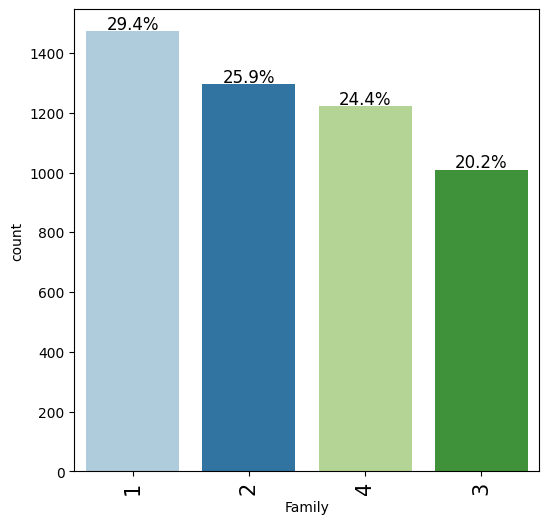

In [ ]:
# Doing univariate analysis on the Family column
# Doing a barplot to get an idea of the values in this column
labeled_barplot(data,'Family', perc=True);

- *We see that we have around 30% of the customers who are single and that is the largest percentage of customers in the dataset.*
- *We also see that the max count we have for family is 4, so we dont have data on very large families of 5 people or more.*

#### **Observations on Experience**

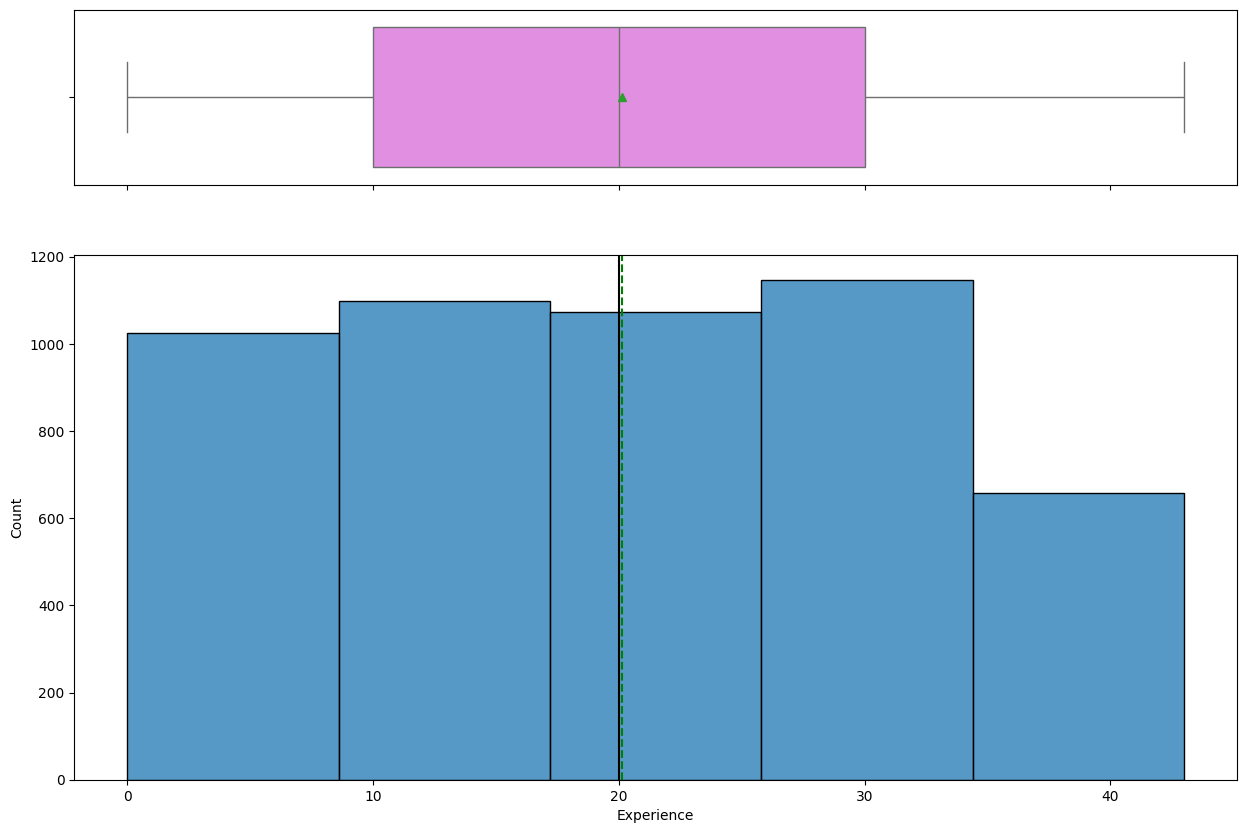

In [ ]:
# Doing univariate analysis on the Experience column
# Doing a histplot and boxplot to get an idea of the values in this column
histogram_boxplot(data, "Experience", bins=5)


- *We have customers with experience ranging from 0 to 43 years.*
- *The data is not skewed and does not have any outliers.*
- *We also see that 50% of the customers have less than 20 years of experience.*

#### **Observations on Income**

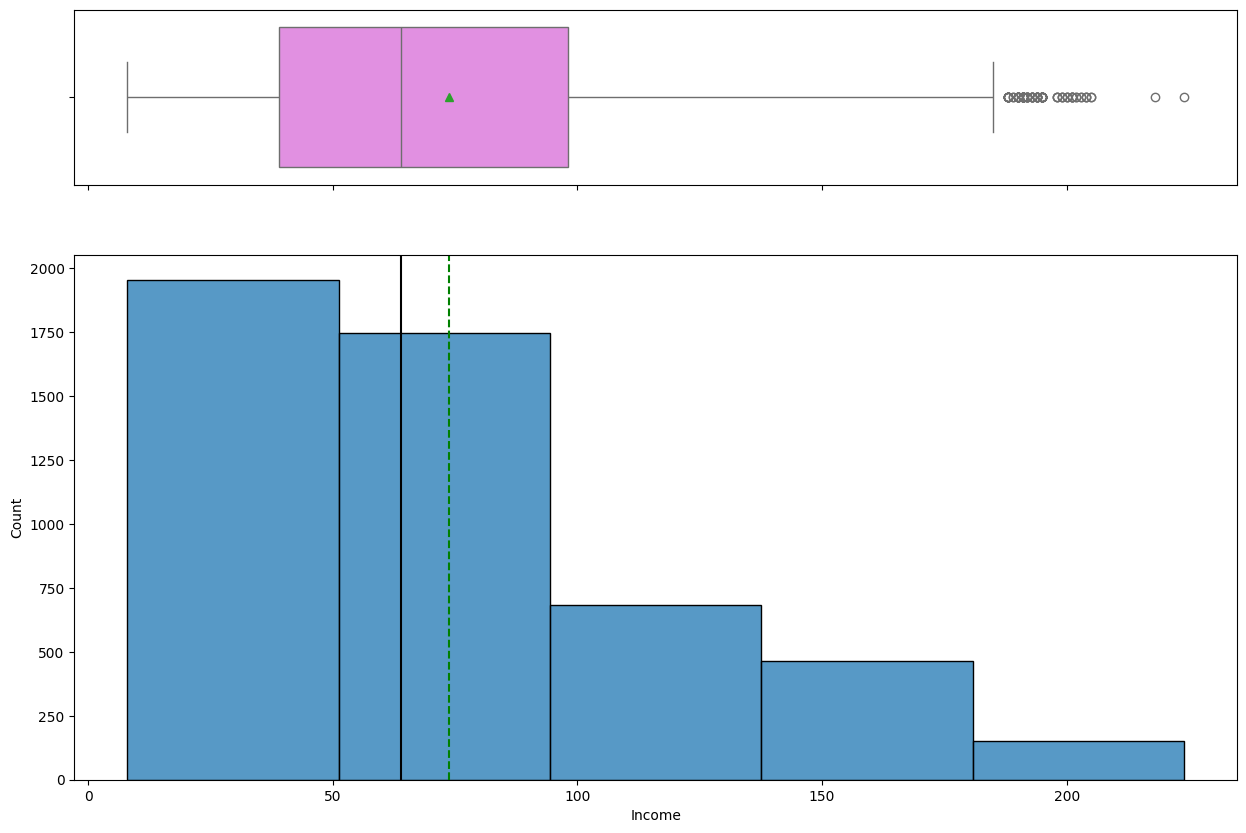

In [ ]:
# Doing univariate analysis on the Income column
# Doing a histplot to get an idea of the values in this column
#labeled_barplot(data,'Experience', perc=True);
histogram_boxplot(data, "Income", bins=5)

- *We see that the data is right skewed and has many outliers.*
- *We observe that 50% of the customers make less than 65 thousand annually.*
- *We see that 75% of the customers make less than 100 thousand annually.*

#### **Observations on CD_Account and Securities_Account**

<ipython-input-13-d1ac9fe6a02c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


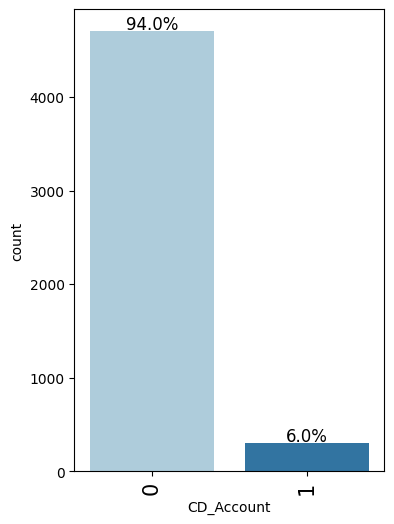

<ipython-input-13-d1ac9fe6a02c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


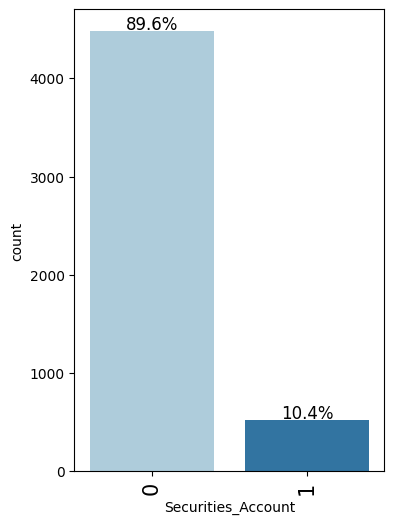

In [ ]:
# Doing univariate analysis on the CD_Account and Securities Account column
# Doing a barplot to get an idea of the values in this column
labeled_barplot(data,'CD_Account', perc=True);
labeled_barplot(data,'Securities_Account', perc=True);

- *We see that 94% of customers have a CD account while around 90% have a securities account with the bank.*
- *This also shows that the customers are interested in products offered by the bank.*

#### **Observations on Personal_Loan**

<ipython-input-13-d1ac9fe6a02c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


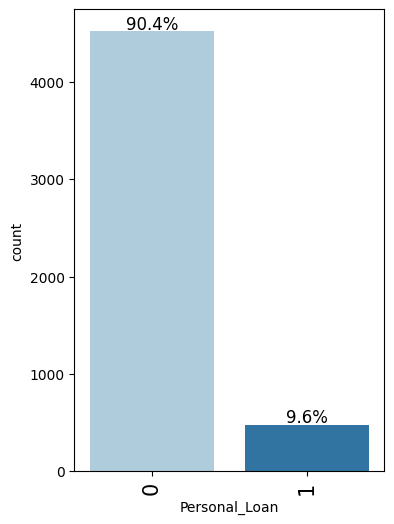

In [ ]:
# Doing univariate analysis on the Personal_Loan  column
# Doing a barplot to get an idea of the values in this column
labeled_barplot(data,'Personal_Loan', perc=True);

- *We observe that only 9.6% of customers took the personal loan offered in last campaign.*

### Bivariate and MultiVariate Analysis

#### **Checking correlation of the columns by Heatmap**

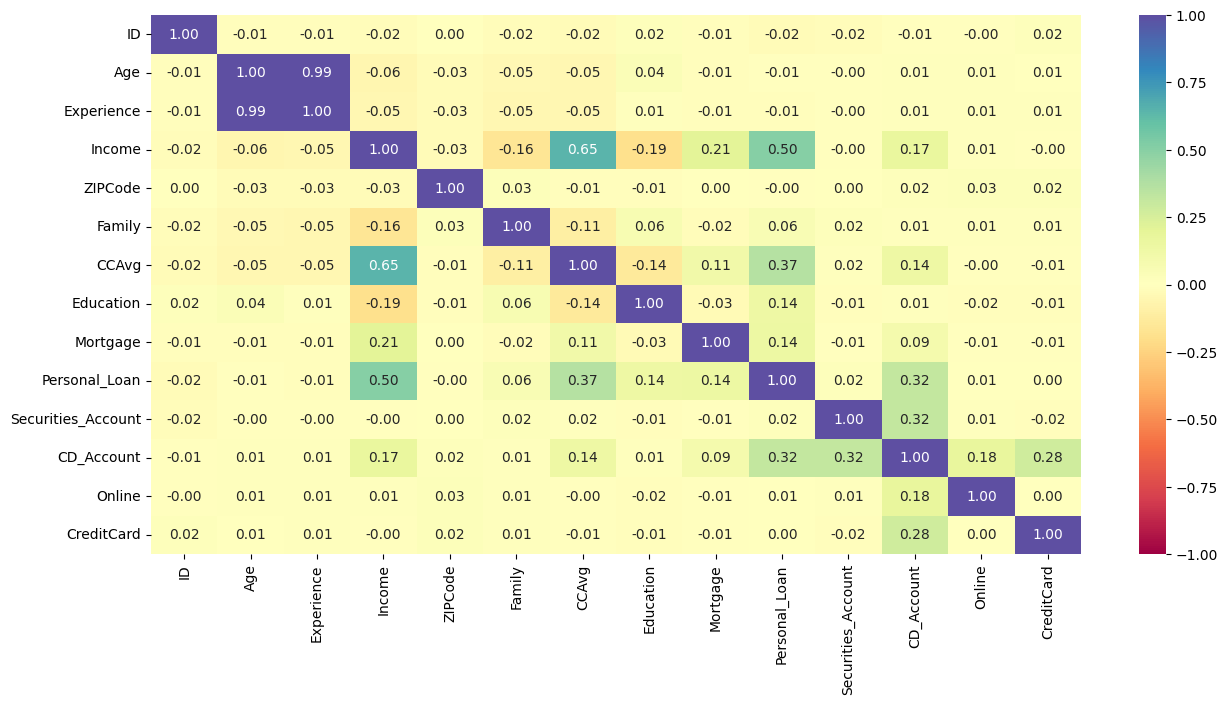

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

- *We see a high positive correlation between experience and Age which is expected since as age increases, work experience would also increase.*
- *We see a moderate positive correlation between Income and CCAvg.*
- *We see a moderate positive correlation between Income and Personal Loan.*
- *We observe that none of the features have a strong correlation to personal loan.*


#### **Exploring relation between age and personal loan**

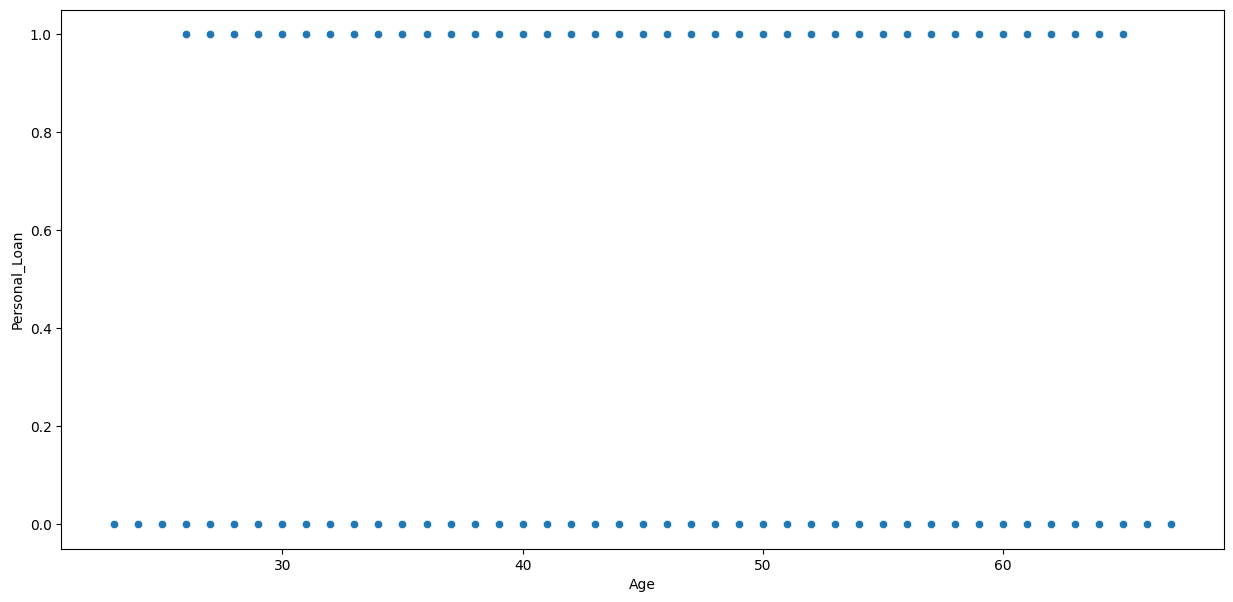

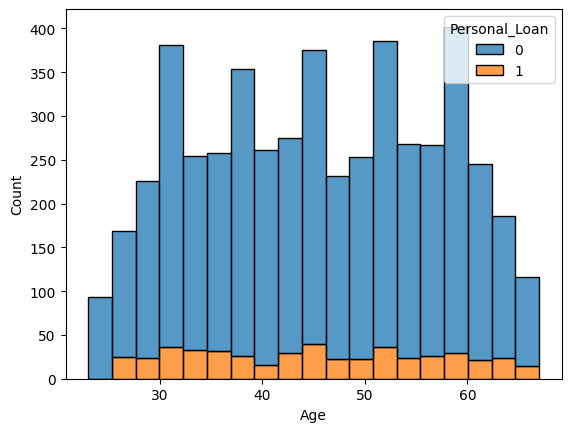

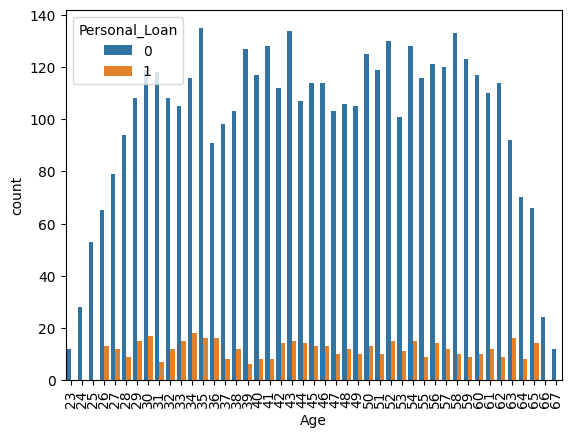

In [ ]:
# Using a scatterplot to explore this relationship
plt.figure(figsize=(15, 7))
sns.scatterplot(data=data, x='Age', y='Personal_Loan')
plt.show()
# Using a histplot to explore this relationship
sns.histplot(data=data, x="Age", hue="Personal_Loan", multiple="stack")
plt.show()
# Using a countplot to explore this relationship
sns.countplot(x='Age', hue='Personal_Loan', data=data)
plt.xticks(rotation=90)
plt.show()

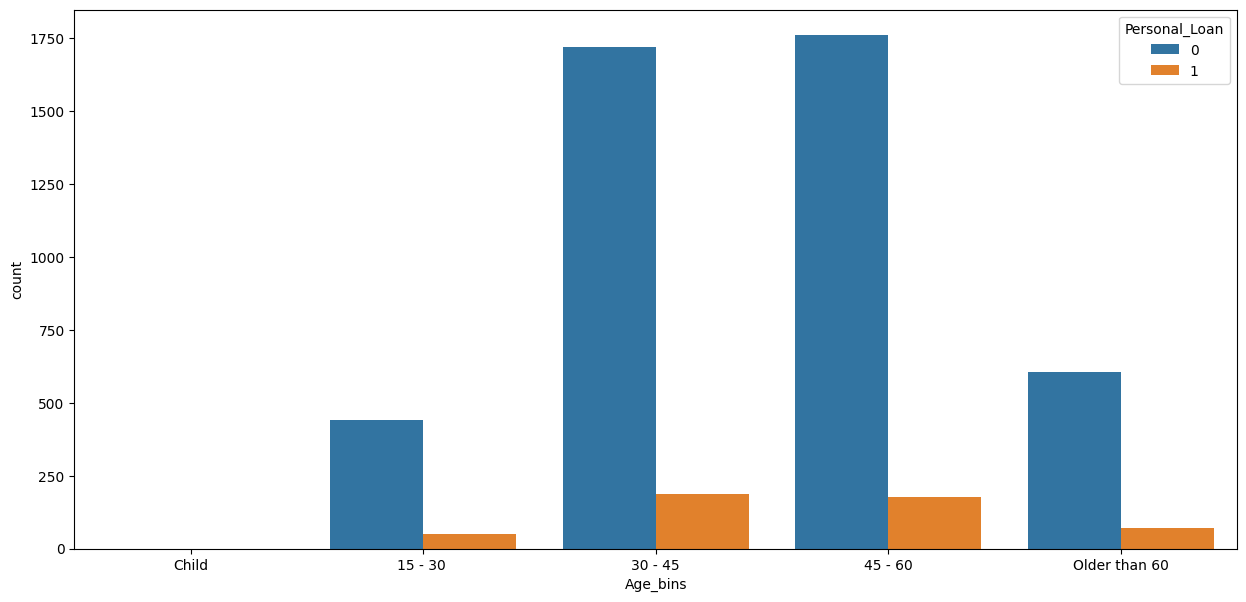

In [ ]:
# To get another perspective on this, want to create some bins with age values in increasing order
# Creating bins of Ages  0 to 15, 15 -30, 30 - 45, 45 -60 and 60 -70
# this will give us an idea of which age group has the most personal loans.
# Setting right parameter to False, so that the bins are left-inclusive and right-exclusive,
# meaning that the rightmost edge of each bin is not included in the bin, but would be included in the next bin.

data['Age_bins'] = pd.cut(data['Age'], bins=[0, 15, 30, 45, 60, 70], labels=['Child','15 - 30 ', '30 - 45', '45 - 60', 'Older than 60'], right=False)
plt.figure(figsize=(15, 7))
sns.countplot(data=data, x='Age_bins', hue='Personal_Loan')
plt.show()


- *We observe that of the customers who did take Personal loans from the bank, they age between 26 and 66.*
- *We also see that customers in the age range of 30 to 60 took most of the loans.*
- *So the bank should target these customers for further campaigns.*

#### **Exploring relation between Education and personal loan**

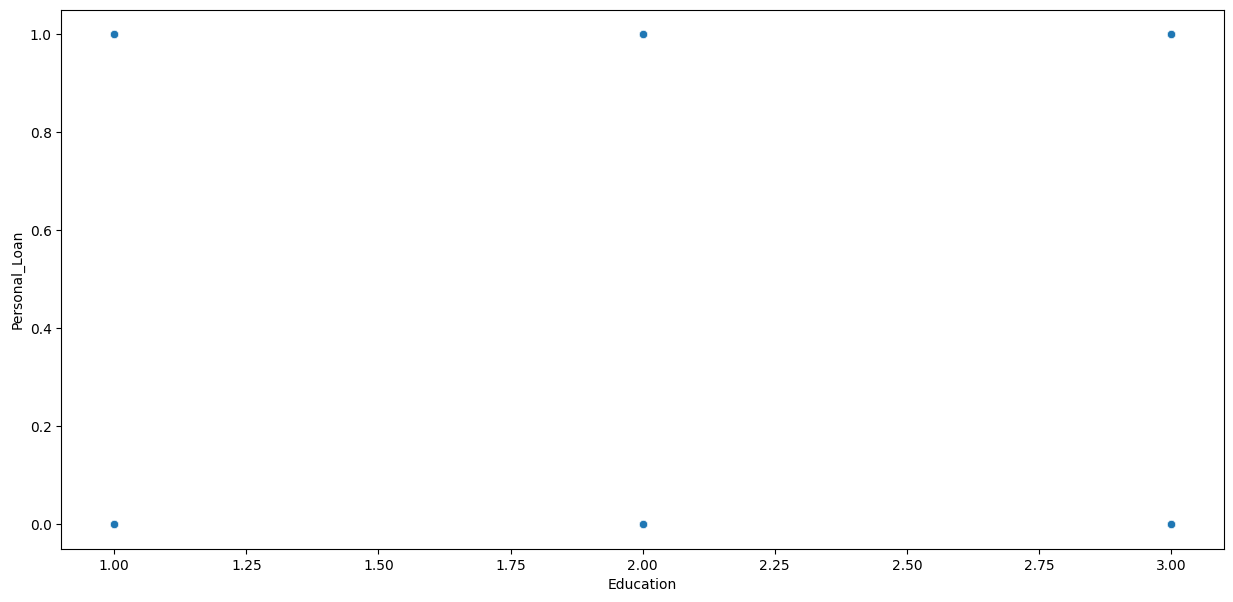

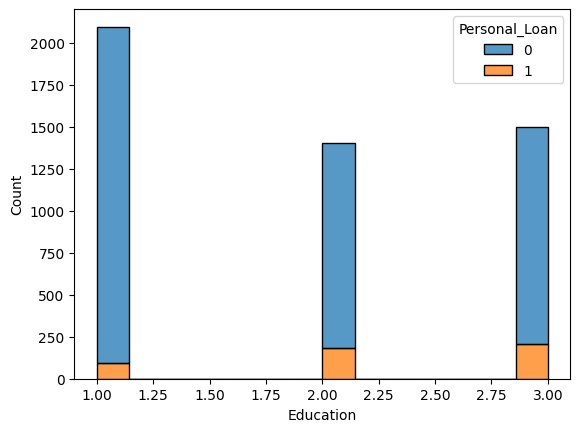

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


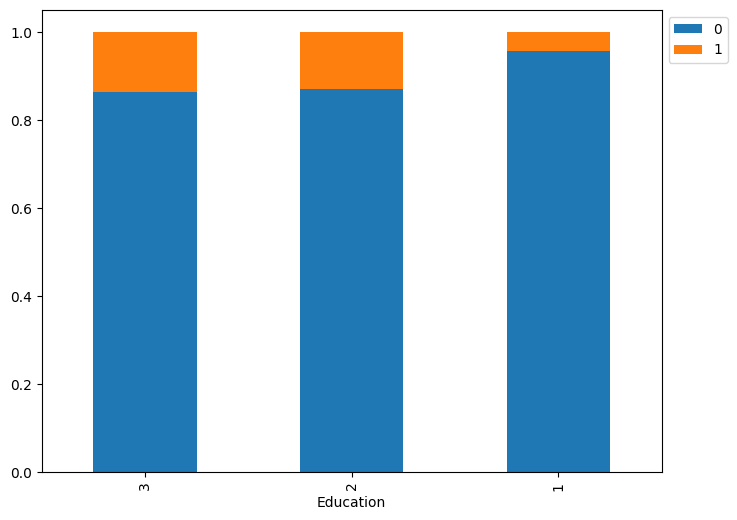

In [ ]:
# Using a scatterplot to explore this relationship
plt.figure(figsize=(15, 7))
sns.scatterplot(data=data, x='Education', y='Personal_Loan')
plt.show()
# Using a histplot to explore this relationship
sns.histplot(data=data, x="Education", hue="Personal_Loan", multiple="stack")
plt.show()

# Using a lineplot to explore this relationship
stacked_barplot( data, "Education", "Personal_Loan")
plt.show()

- *We observe from the plots that customers with higher education of Advanced-Professional have taken more loans compared to customers with lower education.*
- *So the bank could target more of these customers with higher education in their future loan campaigns.*

#### **Exploring relationship between Income and Personal Loan**

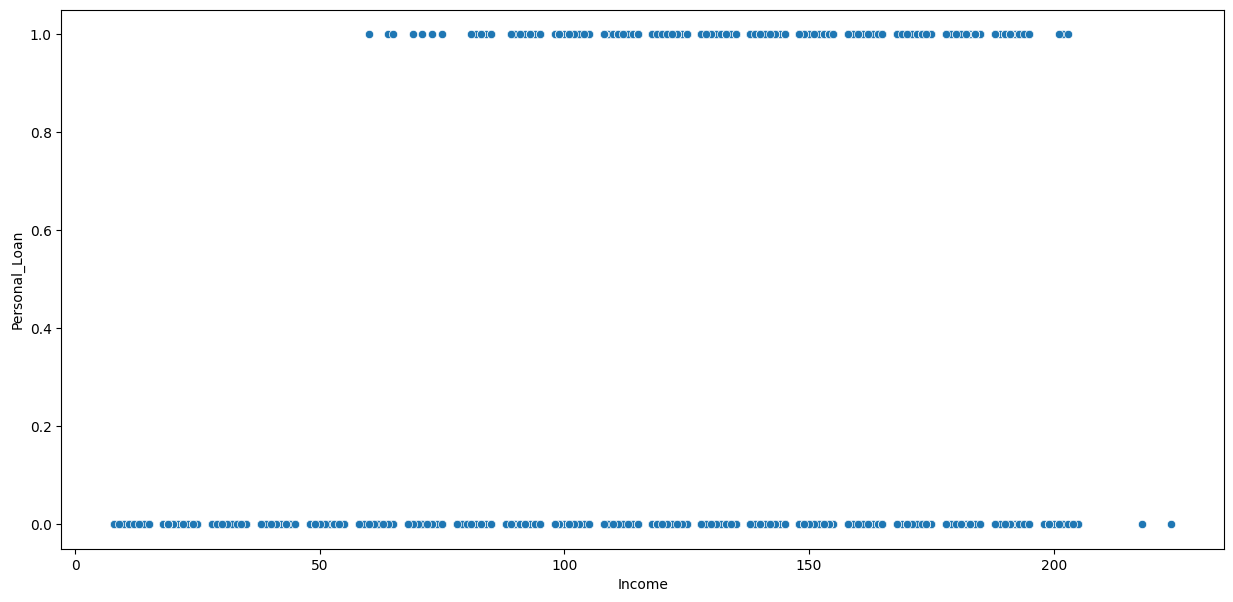

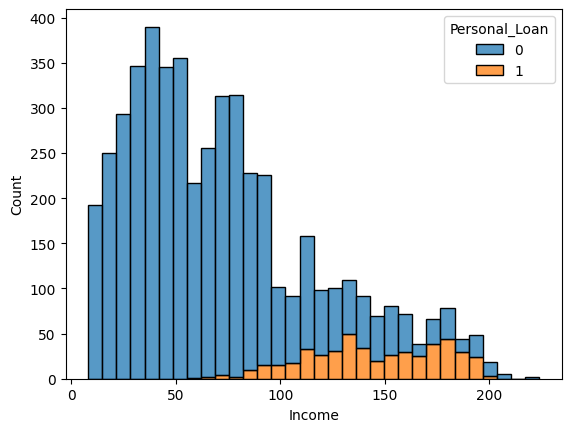

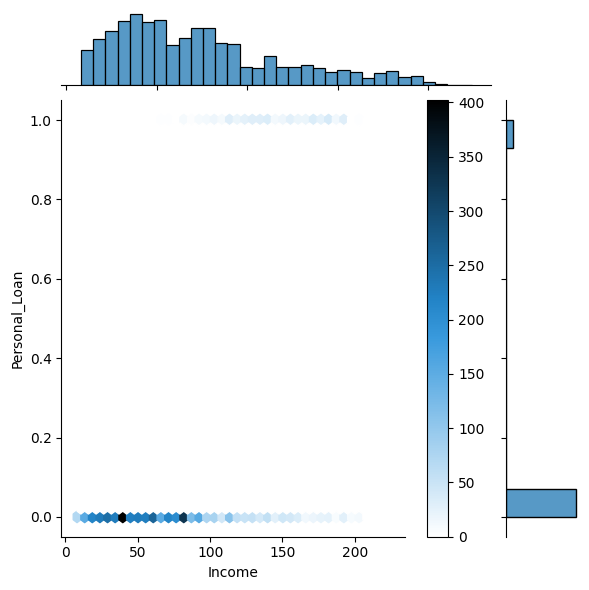

In [ ]:
# Using a scatterplot to explore this relationship
plt.figure(figsize=(15, 7))
sns.scatterplot(data=data, x='Income', y='Personal_Loan')
plt.show()
# Using a histplot to explore this relationship
sns.histplot(data=data, x="Income", hue="Personal_Loan", multiple="stack")
plt.show()

# Using a jointplot to explore
sns.jointplot(data=data, x='Income', y='Personal_Loan', kind='hex')
# adds a separate axis indicating the color scale in this plot
plt.colorbar()
plt.show();


- *We observe that customers with income of 75,000 to 200,000 have purchased most of the personal loans.*

#### **Exploring relationship between ZipCode and Personal Loan**

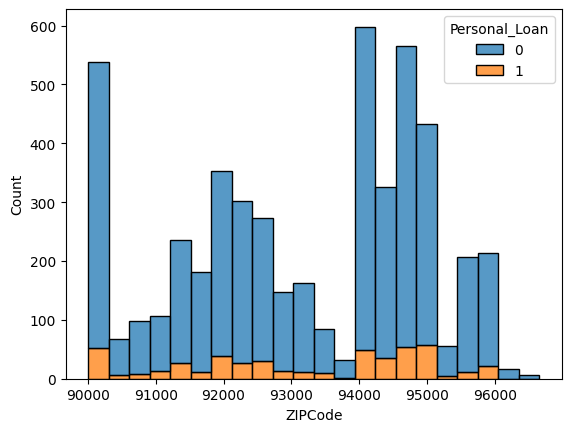

In [ ]:
# Using a histplot to explore this relationship
sns.histplot(data=data, x="ZIPCode", hue="Personal_Loan", multiple="stack")
plt.show()


- *We see that certain zip codes have a higher percentage of customers who took the personal loan.*
- *This could be because these zip codes have higher income customers*

#### **Exploring relationship between Income, Education and Personal Loan**

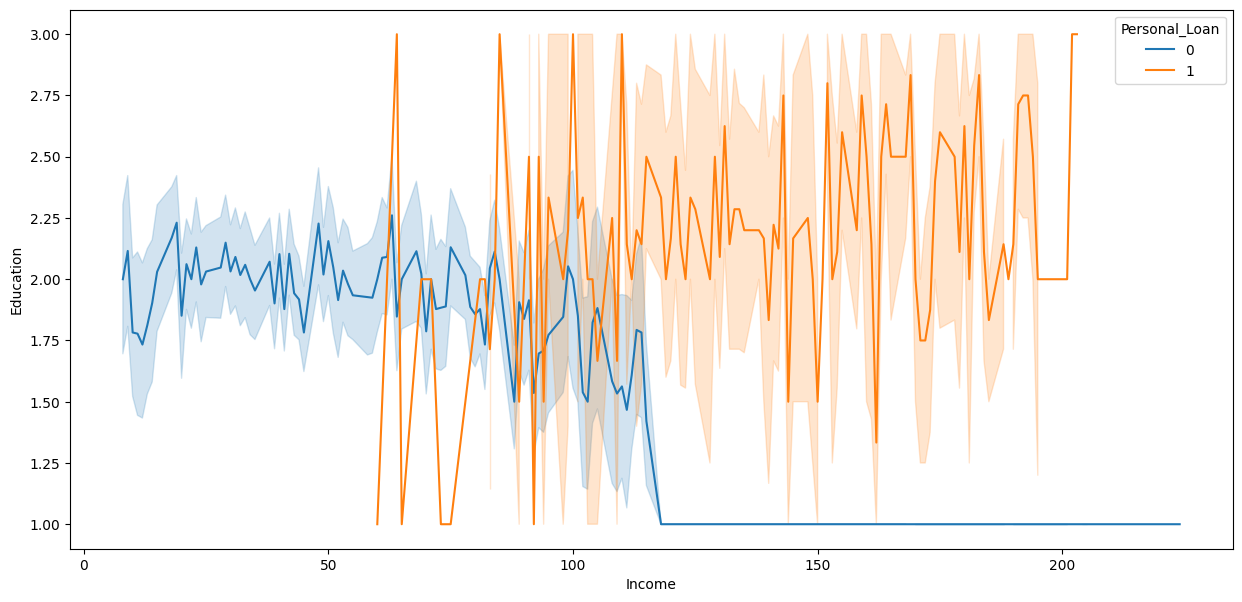

In [ ]:
# Using a line plot to explore this relation.
# Setting Hue to Personal loan

plt.figure(figsize=(15, 7))
sns.lineplot(x='Income', y='Education', data=data, hue="Personal_Loan")
plt.show()

- *We observe that customers with income higher than around 90 thousand and education of 2-Graduate or higher have a higher chance of accepting the personal loan offers.*

#### **Exploring relationship between CCAvg and Personal Loan**




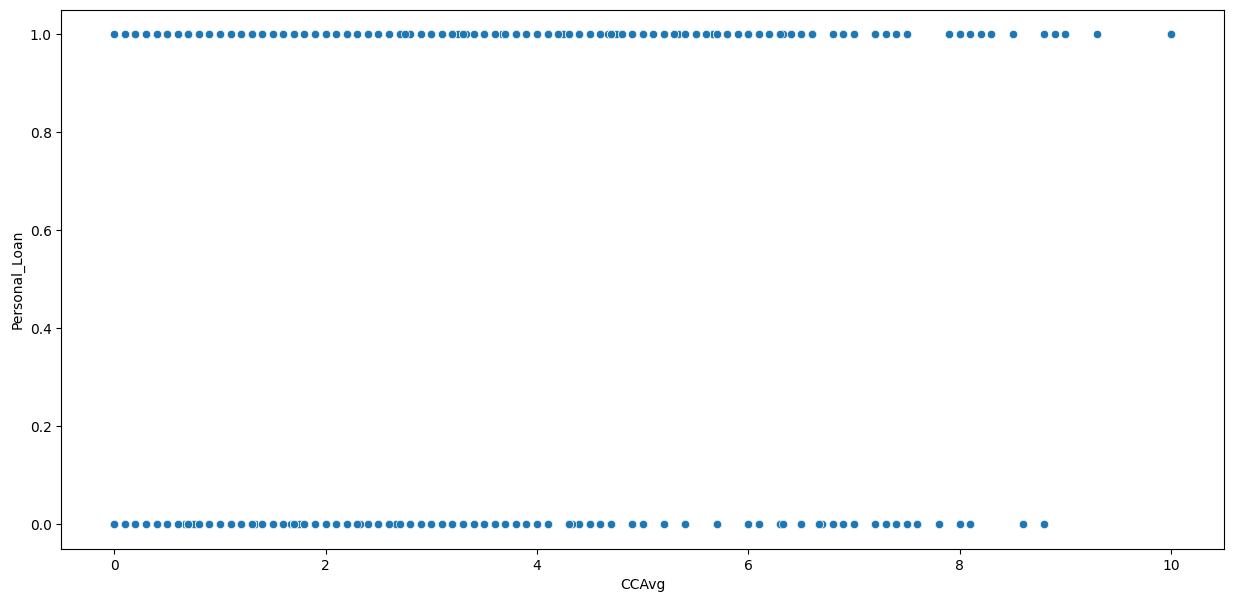

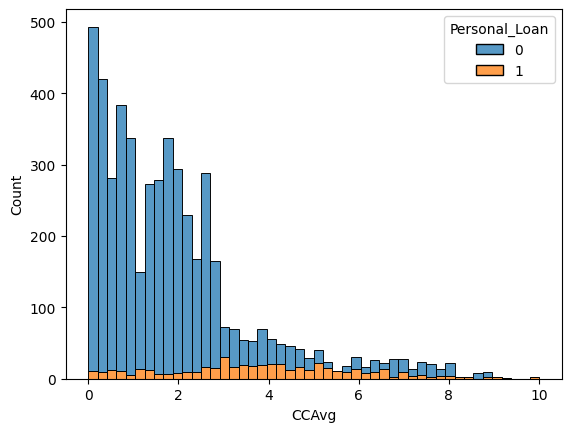

Personal_Loan     0    1   All
CCAvg                         
All            4520  480  5000
3.0              34   19    53
3.4              26   13    39
4.1               9   13    22
3.1               8   12    20
...             ...  ...   ...
6.67              9    0     9
6.7               9    0     9
7.8               9    0     9
7.6               9    0     9
8.6               8    0     8

[109 rows x 3 columns]
------------------------------------------------------------------------------------------------------------------------


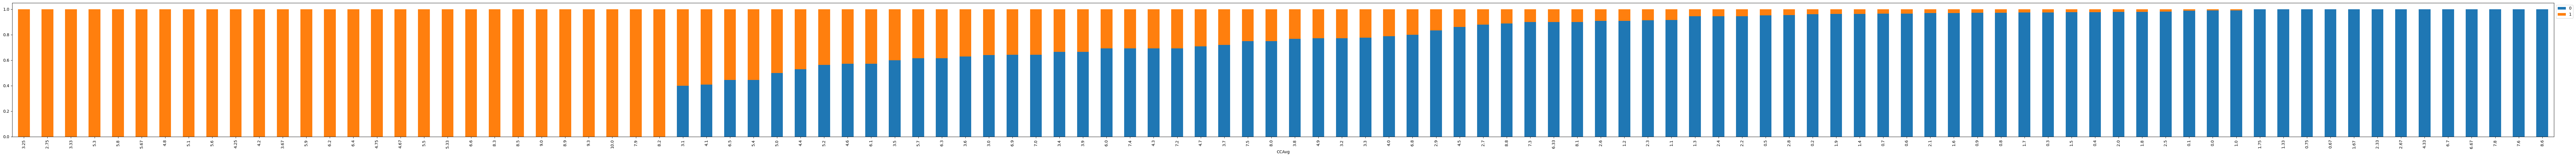

In [ ]:
# Using a scatterplot to explore this relationship
plt.figure(figsize=(15, 7))
sns.scatterplot(data=data, x='CCAvg', y='Personal_Loan')
plt.show()
# Using a histplot to explore this relationship
sns.histplot(data=data, x="CCAvg", hue="Personal_Loan", multiple="stack")
plt.show()

# Using a lineplot to explore this relationship
stacked_barplot( data, "CCAvg", "Personal_Loan")
plt.show()

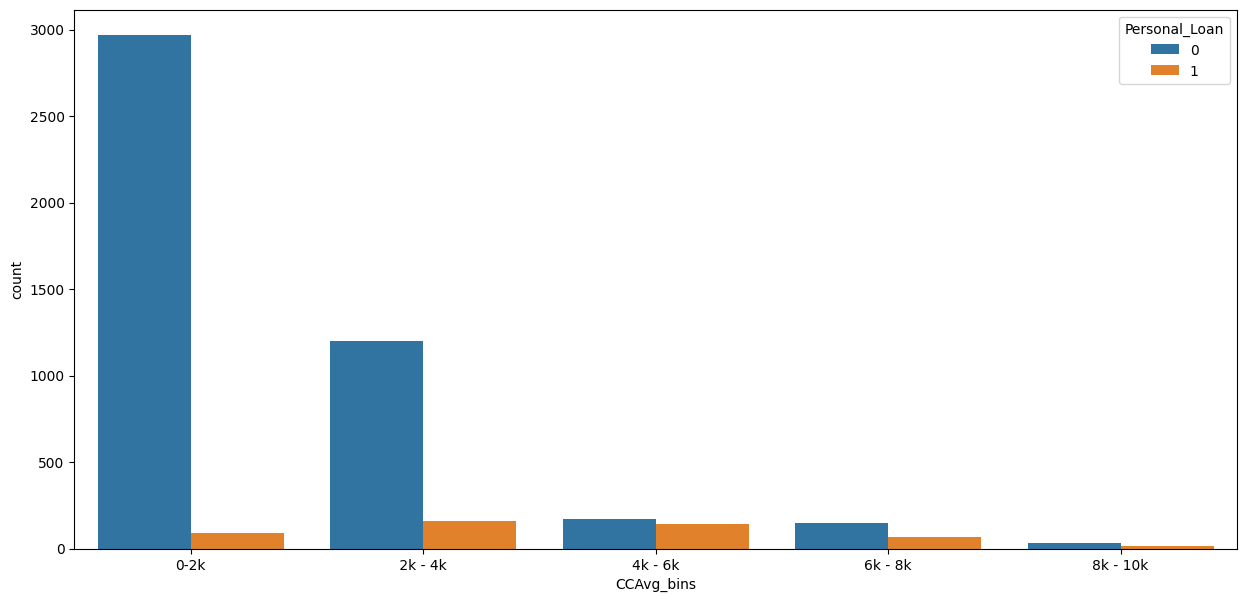

In [ ]:
# To get another perspective on this, want to create some bins with credit card avg spending values in increasing order
# Creating bins of CCAvg  0 to 2, 15 -30, 30 - 45, 45 -60 and 60 -70
# this will give us an idea of which  group has the most personal loans.
# Setting right parameter to False, so that the bins are left-inclusive and right-exclusive,
# meaning that the rightmost edge of each bin is not included in the bin, but would be included in the next bin.

data['CCAvg_bins'] = pd.cut(data['CCAvg'], bins=[0, 2, 4, 6, 8, 10], labels=['0-2k',' 2k - 4k ', '4k - 6k', '6k - 8k', '8k - 10k'], right=False)
plt.figure(figsize=(15, 7))
sns.countplot(data=data, x='CCAvg_bins', hue='Personal_Loan')
plt.show()

- *We observe that customers with credit card average spending of 2000 to 4000 and 4000 to 6000 have the most personal loans with 6000 - 8000 coming in third.*

#### **Exploring relationship between CD_Account and Personal Loan**


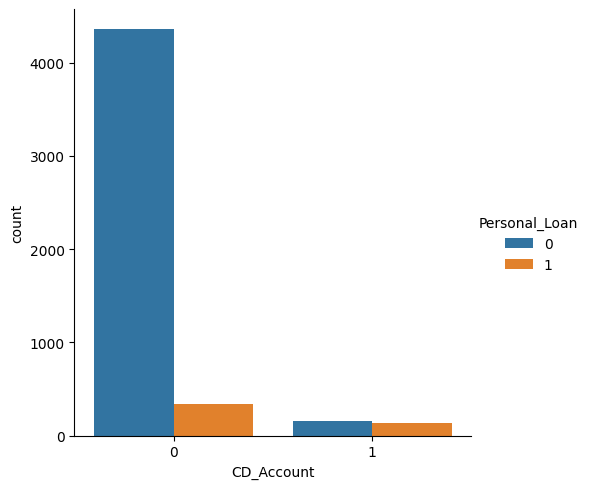

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


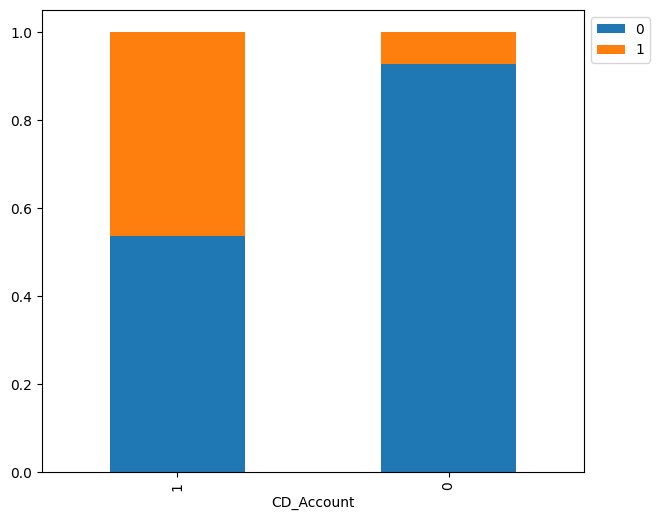

In [ ]:
# Using a bar catplot and barplot to explore this relationship
g = sns.catplot(x='CD_Account', hue='Personal_Loan', kind='count', data=data)
plt.show()
stacked_barplot( data, "CD_Account", "Personal_Loan")
plt.show()

In [ ]:
# We see from the plot that a good percent of customers who have a CD_Account bought a personal loan
#Getting percentage of customers who have CD_Account who have Personal_Loan
count_cd_and_loan = data[(data['CD_Account'] == 1) & (data['Personal_Loan'] == 1)].shape[0]
count_cd = data[data['CD_Account'] == 1].shape[0]
percentage = (count_cd_and_loan / count_cd) * 100

print(f"Percentage of customers with CD_Account who have Personal_Loan: {percentage:.2f}%")

Percentage of customers with CD_Account who have Personal_Loan: 46.36%


- *We observe that almost half of customers who have a CD Account have also bought a personal loan.*

#### **Exploring relationship between Securities_Account and Personal Loan**


Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


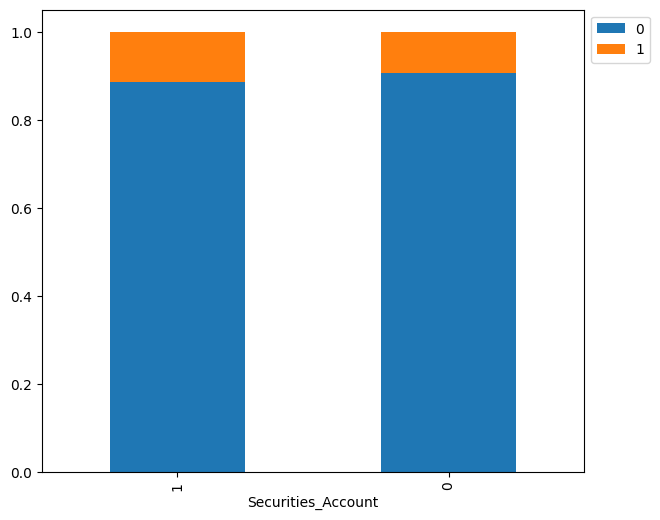

In [ ]:
# Using a barplot to explore the relationship
stacked_barplot( data, "Securities_Account", "Personal_Loan")
plt.show()

- *We observe that an almost equal percent of customers who have and dont have a Securities Account have also bought a personal loan.*

#### **Exploring relationship between Online and Personal Loan**


Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


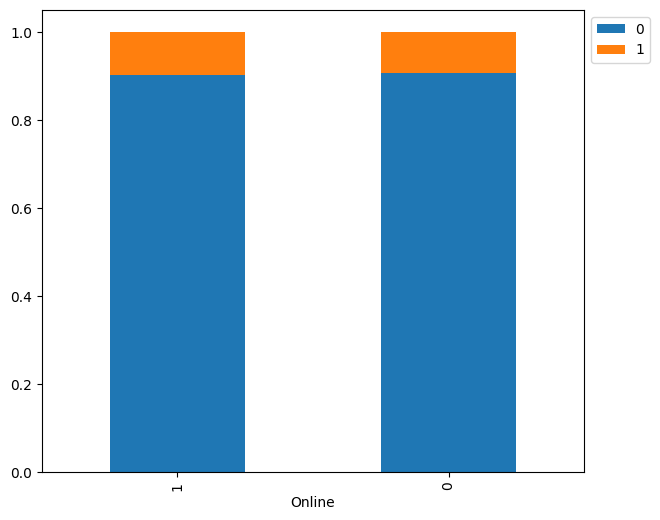

In [ ]:
# Using  a barplot for this
stacked_barplot( data, "Online", "Personal_Loan")
plt.show()

- *We observe that almost equal percent of customers who use and do not use Online banking have bought a Personal Loan.*

#### **Exploring relationship between Family Size and Personal Loan**


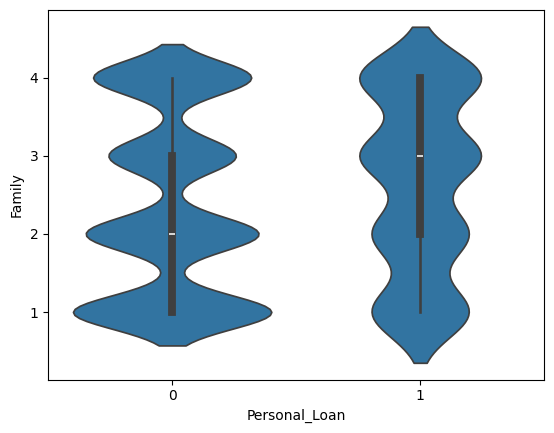

Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


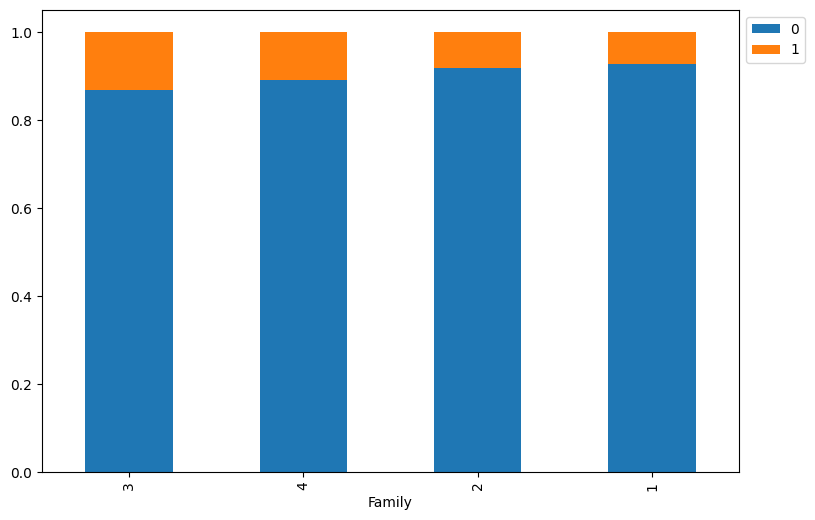

In [ ]:
# Using a  violin plot and barplot for this
sns.violinplot(x='Personal_Loan', y='Family', data=data)
plt.show()
stacked_barplot( data, "Family", "Personal_Loan")
plt.show()


- *We observe that customers with family sizes of 3 and 4 have bought more personal loans compared with family size of 1 or 2.

### Answers To EDA Questions

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
  *   ***The mortgage attribute is right skewed with many outliers.***
  *   ***69 percent of customers do not have a mortgage.***
  *   ***75 percent of customers have less than 101 thousand in mortgage.***
  *   ***Mean of Mortgage is 56.49 thousand while median is 0.***
  *   ***The standard deviation is 101 thousand.***

2. How many customers have credit cards?
  *   ***We see in our analysis from CreditCard column that 1470 customers have external credit cards.***
  *   ***But we also see from our analysis of CCAvg column that only 106 customers dont have a CCAvg value which measures average spending on credit cards per month.***
  *   ***So we could assume that the rest of the customers have credit cards issued by the bank. So the total number of customers with credit cards would be got by subtracting 106 from total number of rows.***
  *   ***So the answer should be 5000 - 106 which is 4894 customers.***
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
  *   ***None of the attributes have a strong correlation with personal loan attribute.***
4. How does a customer's interest in purchasing a loan vary with their age?
  *   ***From our analysis of age with personal loan, we found that only customers between the ages of 26 and 66 took personal loans.***
  *   ***We also observed that customers between the ages of 30 and 60 took the most personal loans.***
5. How does a customer's interest in purchasing a loan vary with their education?
  *   ***From our analysis of education with personal loan, we found that  customers with higher education have more personal loans compared to customers with lower education.***
  *   ***Customers with education of 3-Advanced/Professional have taken more personal loans compared to customers with education of 2-graduate which is greater than customers with education of 1-Undergrad.***
  *   ***So we could generalize and say that customers with higher education are more likely to take personal loans.***

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [ ]:
# We dont have any missing values in the data. So no missing value treatment is needed.
# Even though we have outliers in some of the features, we can keep them as is because outlier removal is generally not needed for Decision tree modelling.

# Preparing data into test and train sets for modelling.
# Dropping the column ID as it does not add any value to the modelling
# Dropping the temporary columns that we created for EDA - Age_bins and CCAvg_bins also
X = data.drop(['ID','Personal_Loan', 'Age_bins', 'CCAvg_bins'], axis=1)
y = data['Personal_Loan']

In [ ]:
# splitting the data in an 80:20 ratio for train and test sets
# stratify ensures that the training and test sets have a similar distribution of the response variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

In [ ]:
# Printing details of train and test set
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape, '\n')
print("Percentage of classes in training set:")
print(100*y_train.value_counts(normalize=True), '\n')
print("Percentage of classes in test set:")
print(100*y_test.value_counts(normalize=True))

Shape of training set: (4000, 12)
Shape of test set: (1000, 12) 

Percentage of classes in training set:
Personal_Loan
0    90.4
1     9.6
Name: proportion, dtype: float64 

Percentage of classes in test set:
Personal_Loan
0    90.4
1     9.6
Name: proportion, dtype: float64


In [ ]:
# Using head function to check the data
X_train.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard
408,60,36,89,91745,2,2.8,1,0,0,0,1,0
3737,44,19,30,91423,1,0.5,3,0,0,0,1,0
3889,26,0,19,93014,1,0.1,2,121,0,0,1,0
568,34,9,41,92101,2,0.1,1,161,0,0,1,1
1041,56,32,51,92780,4,1.5,1,0,0,0,0,0


## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**

1. Predicting a customer will buy a personal loan while in reality the customer did not buy the loan which is a false positive case. The precision metric measures this.

2. Predicting a customer will not buy a personal loan while in reality the customer will buy the loan which is a false negative. The recall metric measures this.

**Which case is more important?**

* In the first case of false positive, the bank could spend resources to acquire this customer who will not buy the loan, which could lead to wastage of bank resources.
* For the second case of False negative, the bank would lose an opportunity of advertising to a potential customer and thus could lose potential customers.
* In our case, the bank is currently just trying to acquire new customers for its personal loan product and not worried about spending resources for it. So  recall would be the metric that the bank is trying to increase.

**Which metric of F1, precision or recall to focus on?**
*  We will attempt to create a model where `recall` is maximized, because greater the recall higher the chances of minimizing false negatives and advertise to as many customers as possible. Since currently the bank is trying to just acquire more customers for its personal loan product and is willing to spend resources to acquire them.


#### Some utility functions to calculate Accuracy, recall, Precision and F1 score.
* The model_performance_classification function will be used to check the model performance of models.
* The make_confusion_matrix function will be used to plot confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model Building with Default Decision Tree

In [ ]:
# Using the default Decision Tree to build the first model
# Using gini as impurity algorithm

model_default = DecisionTreeClassifier(criterion="gini", random_state=1)
model_default.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

### Check performance for train set

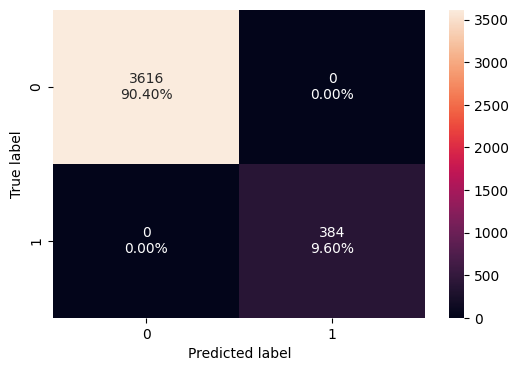

In [ ]:
confusion_matrix_sklearn(model_default, X_train, y_train)

In [ ]:
# Printing Accuracy, recall, Precision and F1 scores

dtree_default_train_perf = model_performance_classification(
    model_default, X_train, y_train
)
dtree_default_train_perf


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


### Check performance for test set

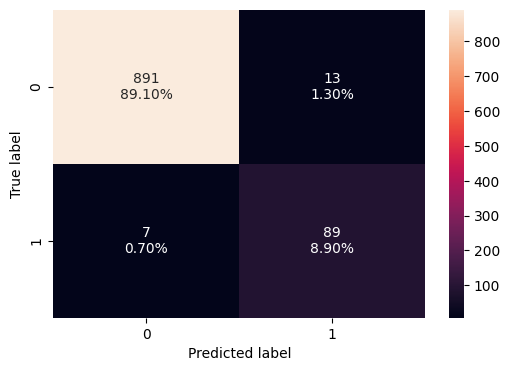

In [ ]:
confusion_matrix_sklearn(model_default, X_test, y_test)

In [ ]:
dtree_default_test_perf = model_performance_classification(
    model_default, X_test, y_test
)
dtree_default_test_perf

,Accuracy,Recall,Precision,F1
0,0.98,0.927083,0.872549,0.89899


- *We observe that on the train set, the scores are the best scores you can get.*
- *But on the test set, the scores are less.*
- *This shows that the model is overfitting.*

#### Visualizing the Decision Tree

In [ ]:
# Getting all the column names into a list
feature_names = list(X.columns)
print(feature_names)

['Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']


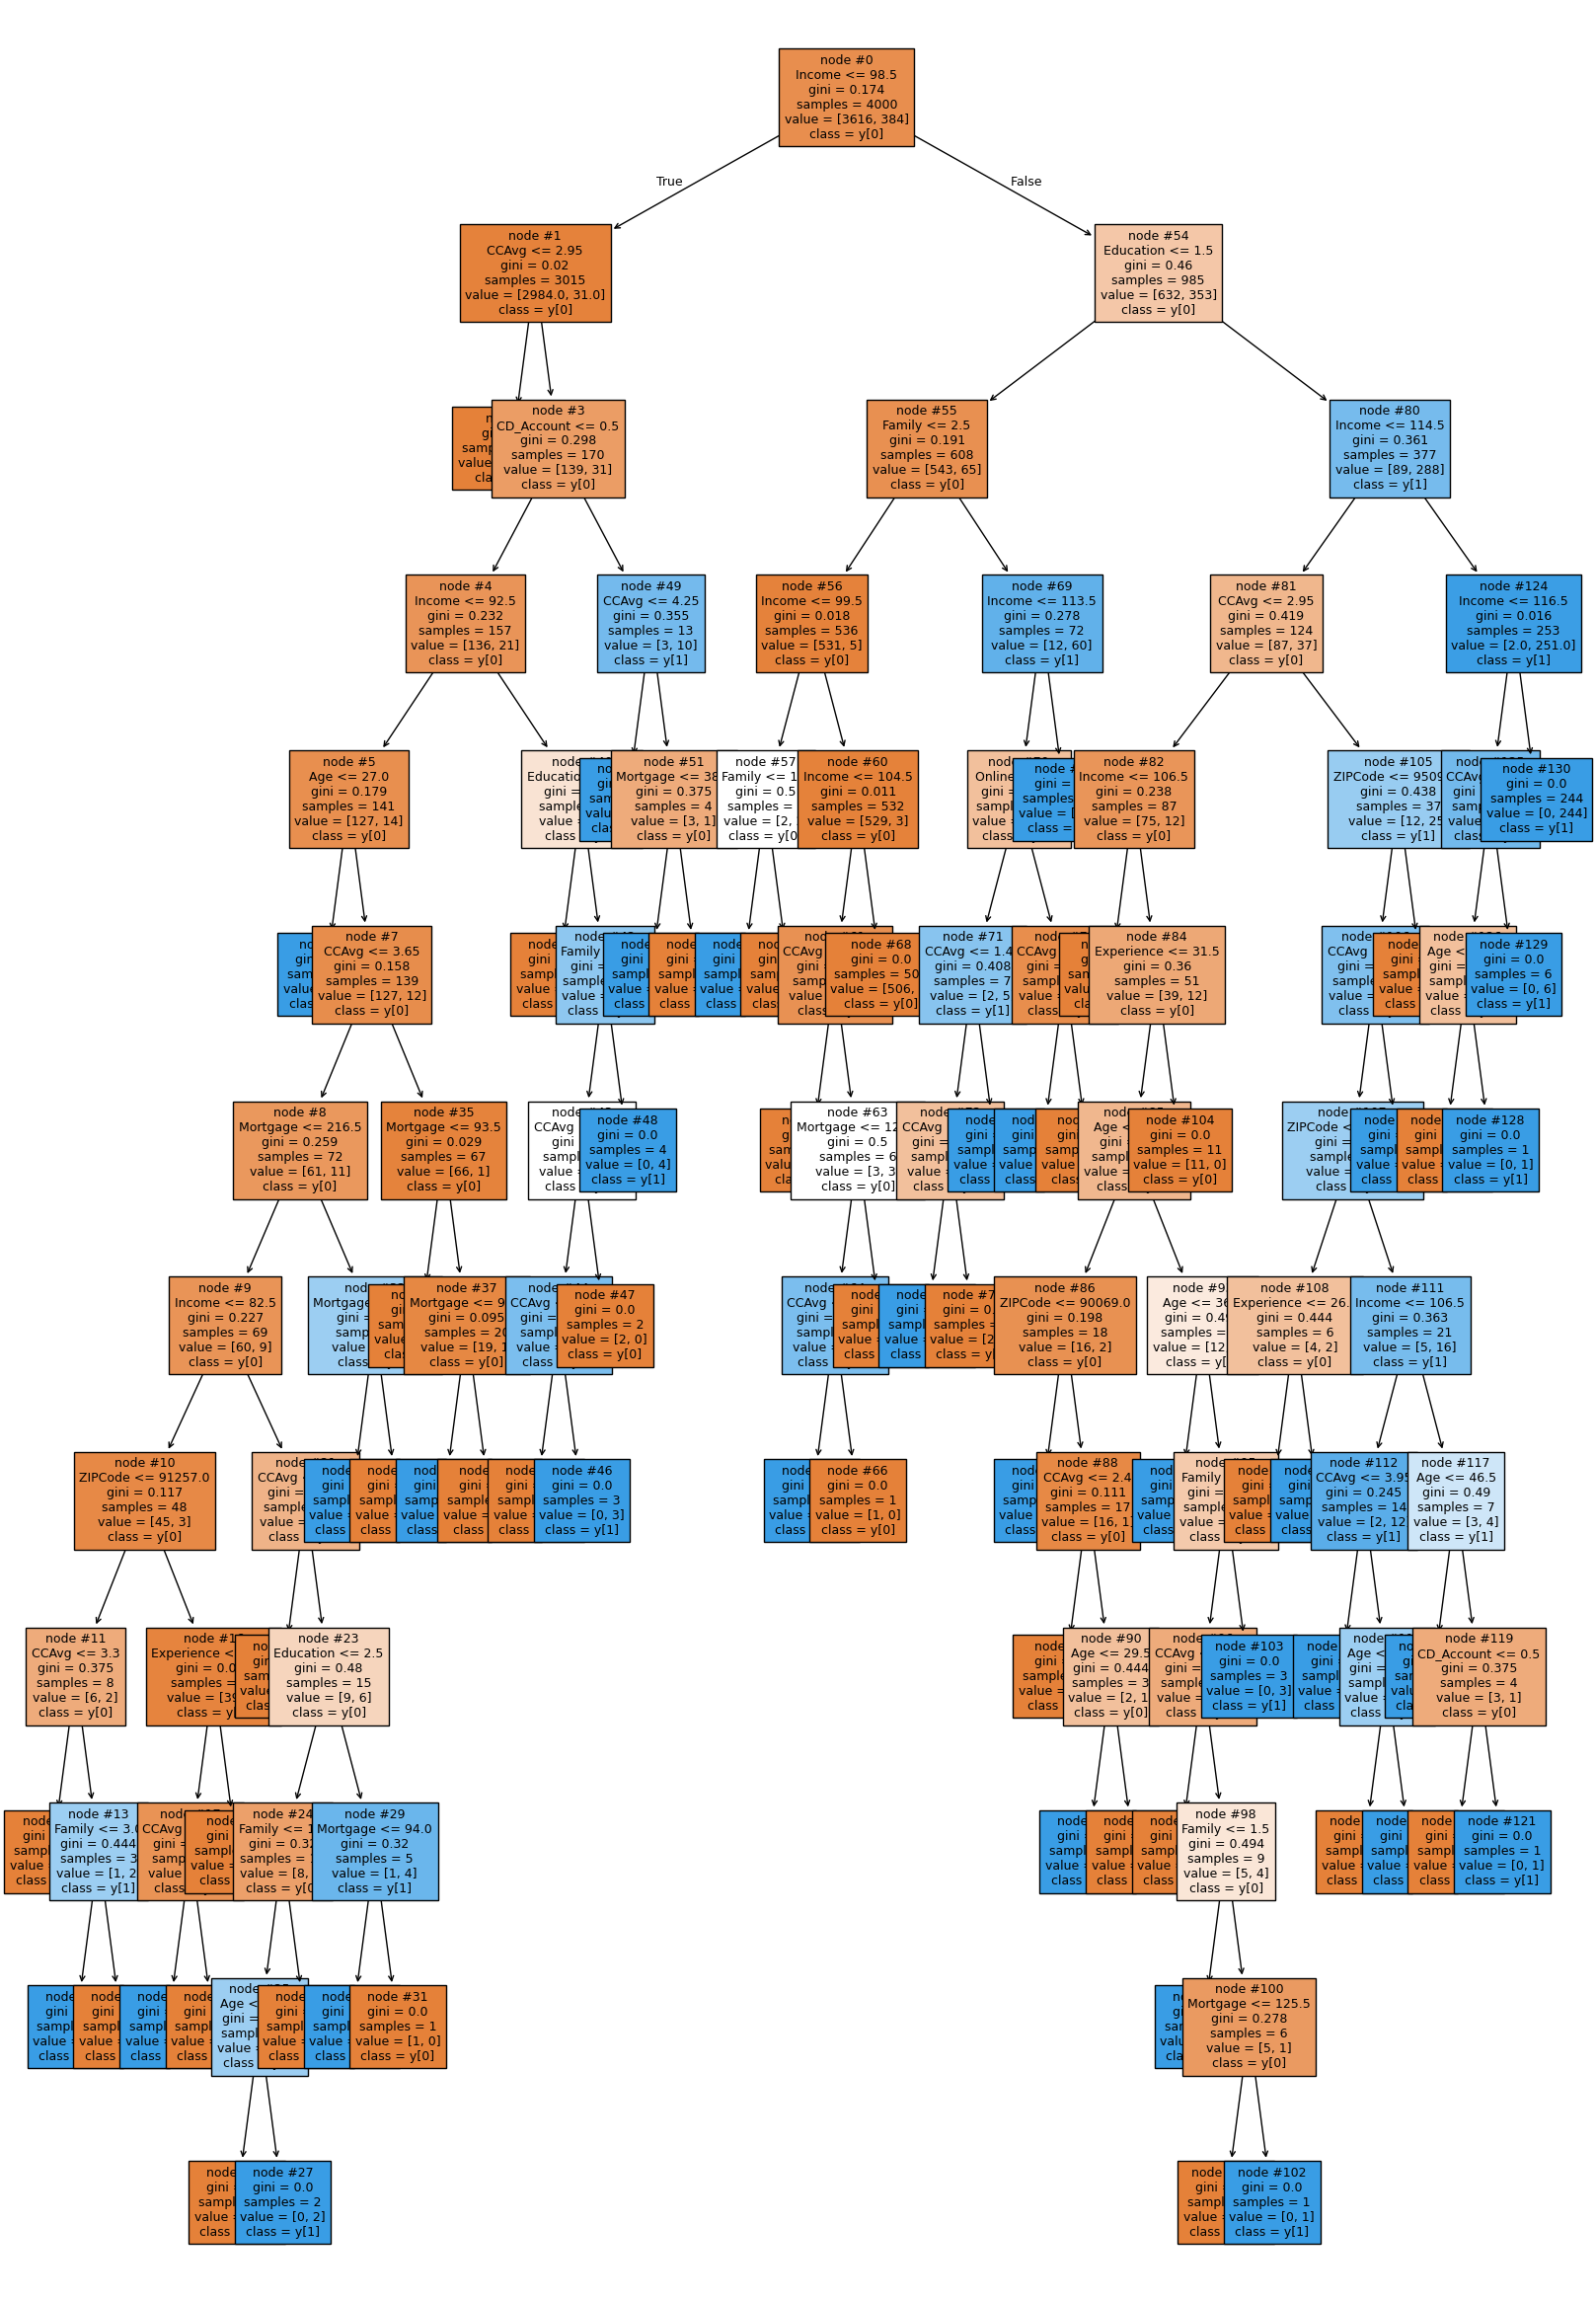

In [ ]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    model_default,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

- *We see that this is a complex decision tree with many levels and nodes.*

In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model_default, feature_names=feature_names, show_weights=True))

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- ZIPCode <= 91257.00
|   |   |   |   |   |   |   |   |   |--- CCAvg <= 3.30
|   |   |   |   |   |   |   |   |   |   |--- weights: [5.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- CCAvg >  3.30
|   |   |   |   |   |   |   |   |   |   |--- Family <= 3.00
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |   |   |   |--- Family >  3.00
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- Z

- *The rules are also very complex with many splits.*

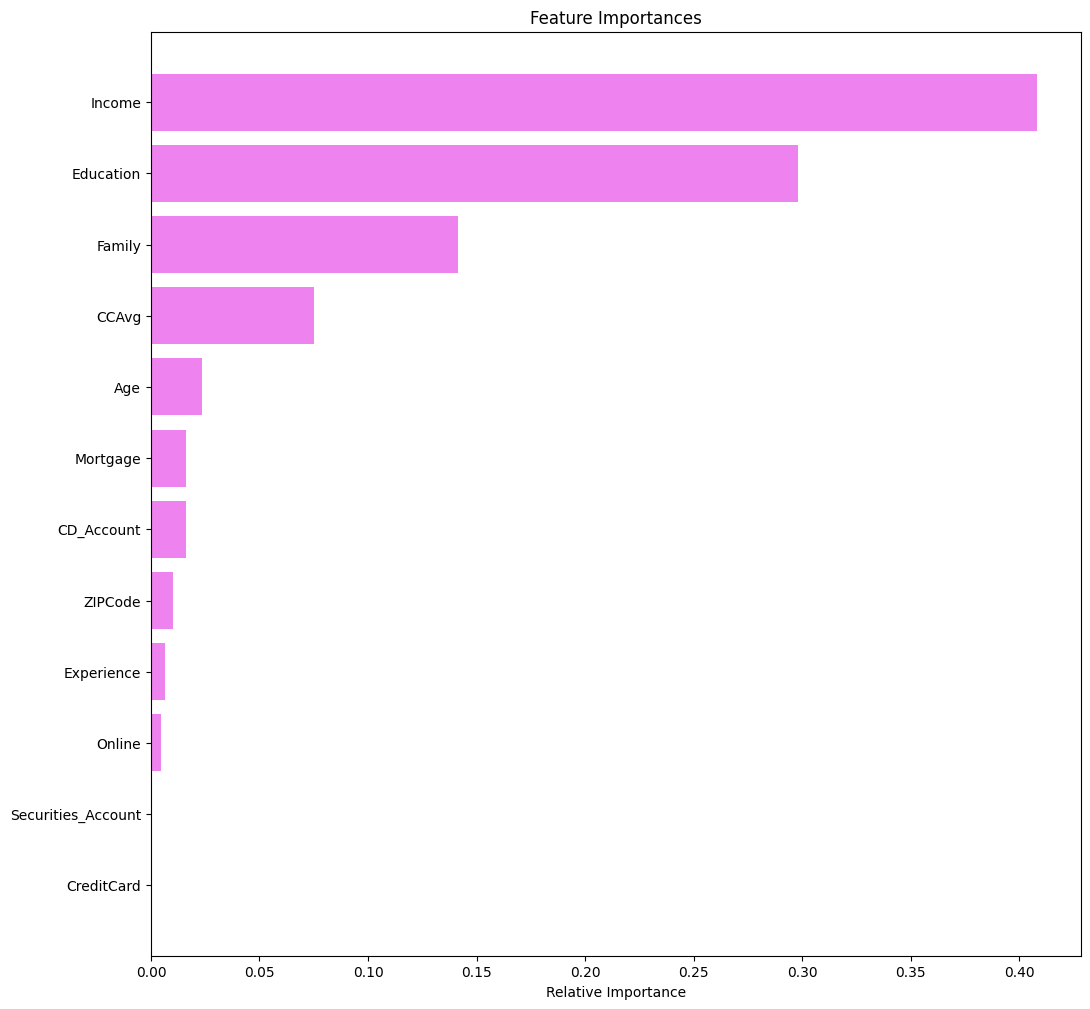

In [ ]:
# Create a plot showing the relative importance of the features in the decision tree
importances = model_default.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- *We observe that 10 features have been used to create this decision tree.*

## Model Performance Improvement

### Decision Tree (Pre-pruning)

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


In [ ]:
# creating an instance of the best model
model_preprune_best = best_estimator

# fitting the best model to the training data
model_preprune_best.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(2),
                       max_leaf_nodes=50, min_samples_split=10,
                       random_state=42)

#### Model Evaluation

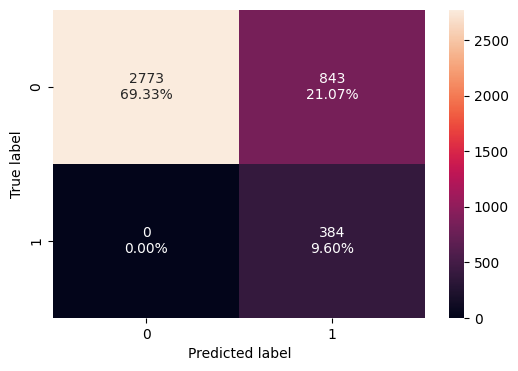

In [ ]:
confusion_matrix_sklearn(model_preprune_best, X_train, y_train)

In [ ]:
dtree_preprune_train_perf = model_performance_classification(
    model_preprune_best, X_train, y_train
)
dtree_preprune_train_perf

,Accuracy,Recall,Precision,F1
0,0.78925,1.0,0.312958,0.476723


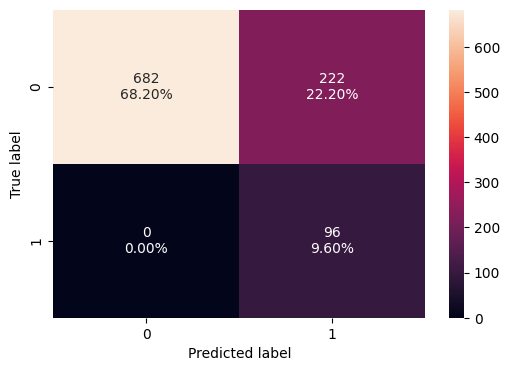

In [ ]:
confusion_matrix_sklearn(model_preprune_best, X_test, y_test)

In [ ]:
dtree_preprune_test_perf = model_performance_classification(
    model_preprune_best, X_test, y_test
)
dtree_preprune_test_perf

,Accuracy,Recall,Precision,F1
0,0.778,1.0,0.301887,0.463768


- *We observe that we have gotten the maximum recall score of 1 on both the train and test sets for the best model.*

#### Visualizing the Model

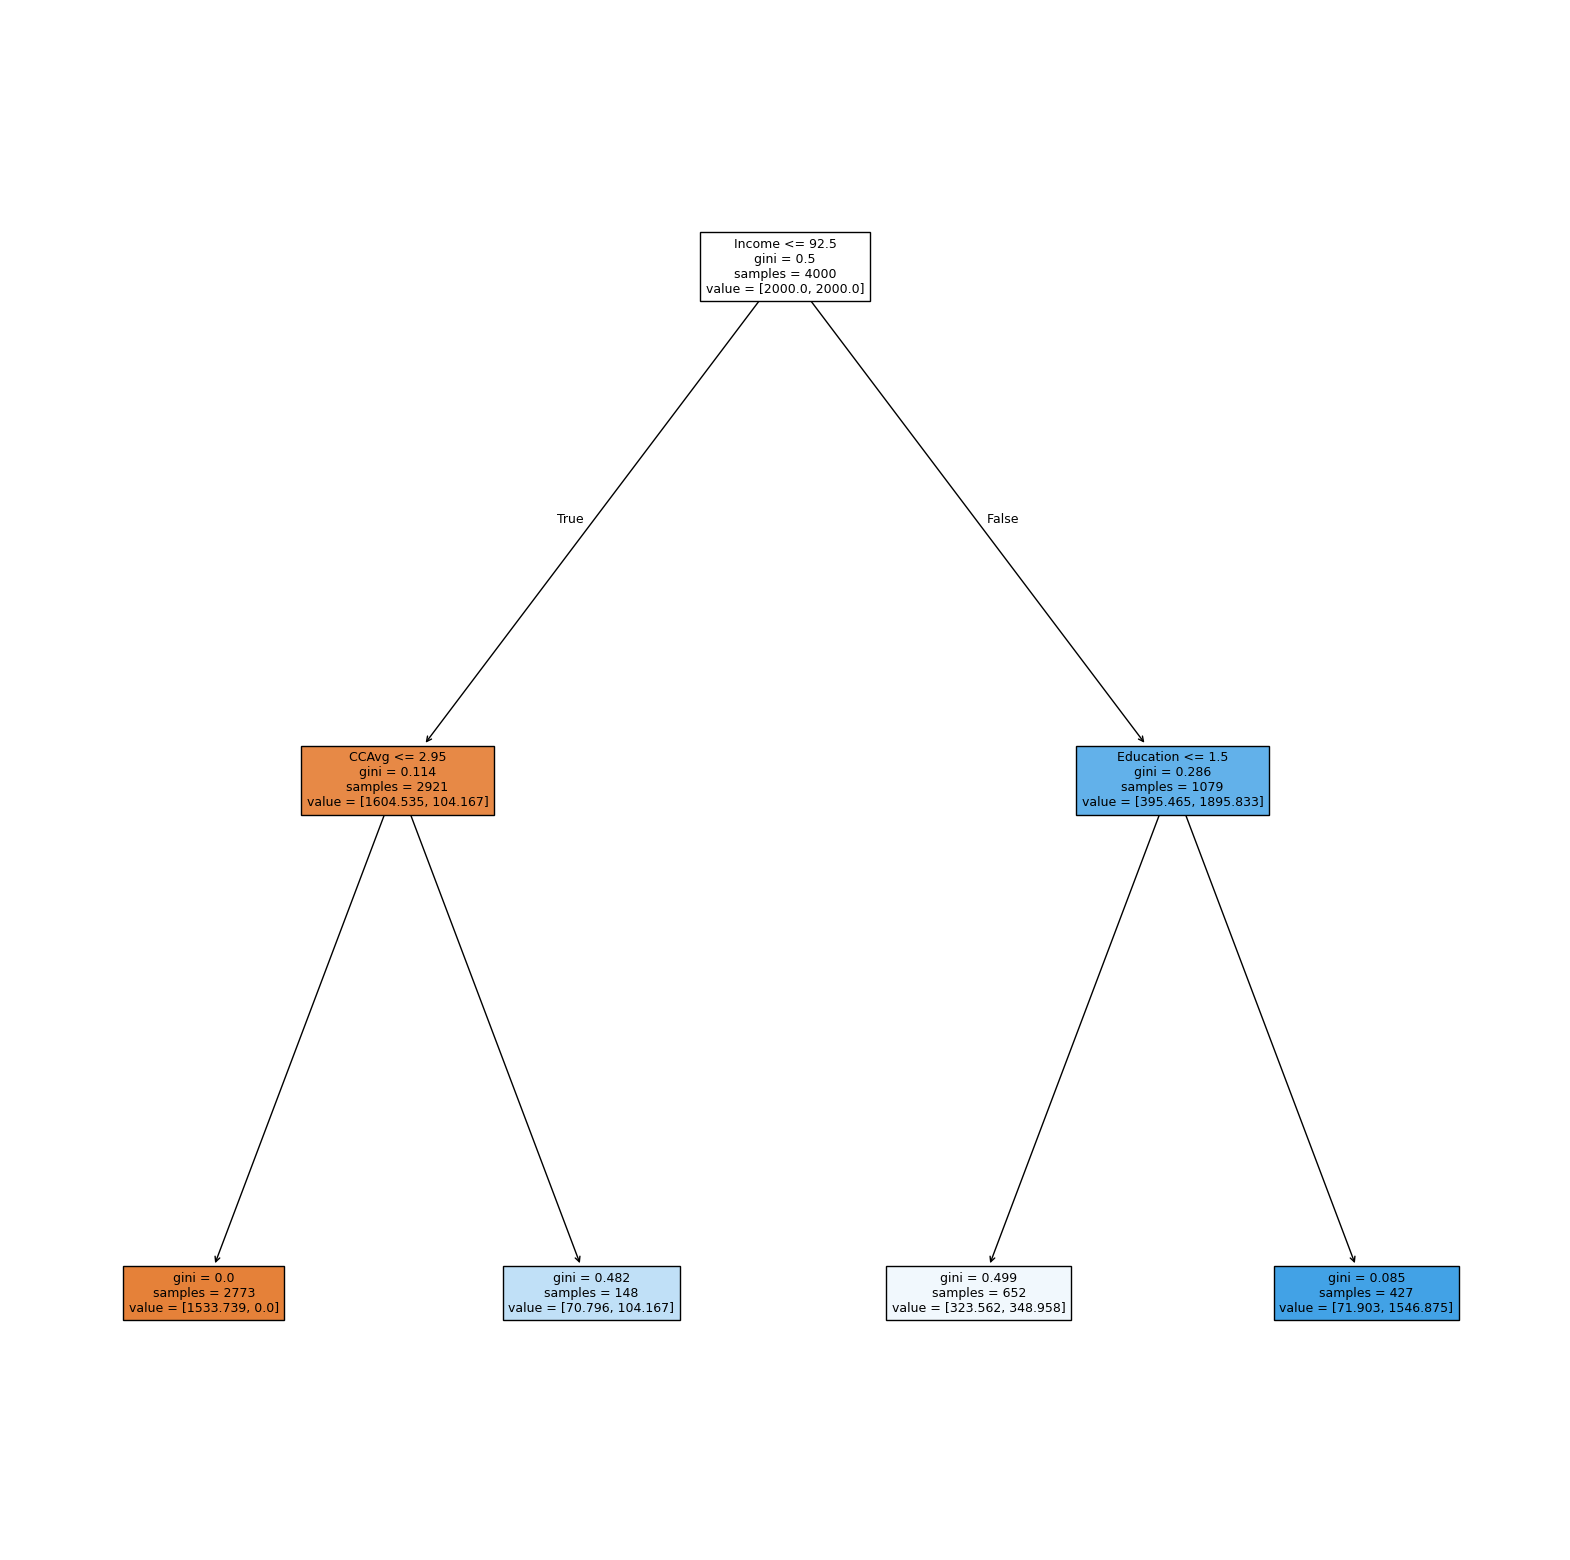

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model_preprune_best,            # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- *We see that the model is much simpler which just 2 levels and 4 leaf nodes.*

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        model_preprune_best,          # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1533.74, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [70.80, 104.17] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- weights: [323.56, 348.96] class: 1
|   |--- Education >  1.50
|   |   |--- weights: [71.90, 1546.87] class: 1



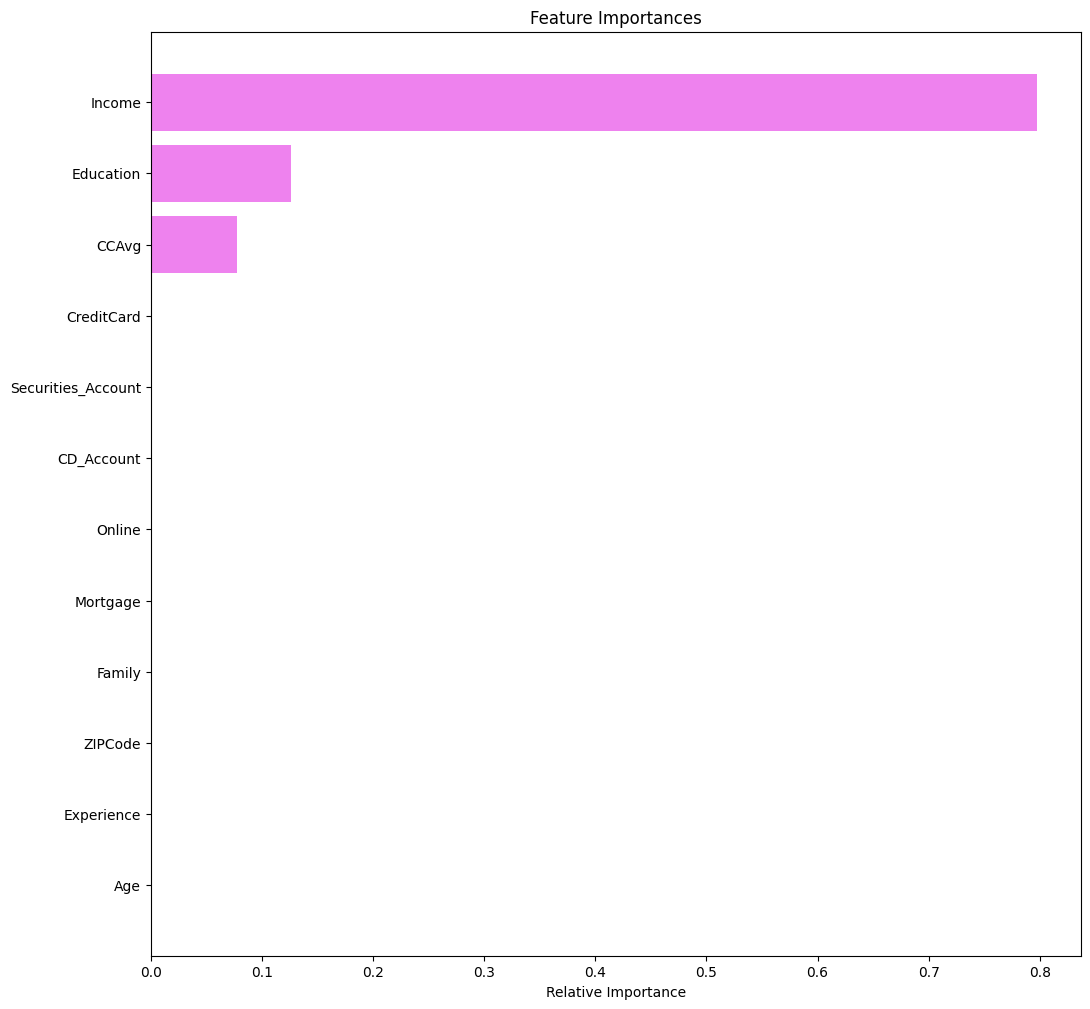

In [ ]:
# Create a plot showing the relative importance of the features in the decision tree
importances = model_preprune_best.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- *We can see that only 3 features have been used in the creation of this decision tree - Income, Education and CCAvg.*

### Decision Tree (Post-pruning)

- Cost complexity pruning provides another option to control the size of a tree.
- In `DecisionTreeClassifier`, this pruning technique is parameterized by the
cost complexity parameter, ``ccp_alpha``.
- Greater values of ``ccp_alpha`` increase the number of nodes pruned.
- Here we only show the effect of ``ccp_alpha`` on regularizing the trees and how to choose the optimal ``ccp_alpha`` value.

**Total impurity of leaves vs effective alphas of pruned tree**

Minimal cost complexity pruning recursively finds the node with the "weakest
link". The weakest link is characterized by an effective alpha, where the
nodes with the smallest effective alpha are pruned first. To get an idea of
what values of ``ccp_alpha`` could be appropriate, scikit-learn provides
`DecisionTreeClassifier.cost_complexity_pruning_path` that returns the
effective alphas and the corresponding total leaf impurities at each step of
the pruning process. As alpha increases, more of the tree is pruned, which
increases the total impurity of its leaves.

In [ ]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-2.776658e-16
1,2.701870e-18,-2.749639e-16
2,2.701870e-18,-2.722620e-16
3,5.204170e-18,-2.670579e-16
4,1.860606e-17,-2.484518e-16
5,1.708933e-16,-7.755851e-17
6,1.915872e-16,1.140286e-16
7,1.353986e-04,2.707972e-04
8,1.362080e-04,5.432132e-04
9,1.369522e-04,8.171175e-04


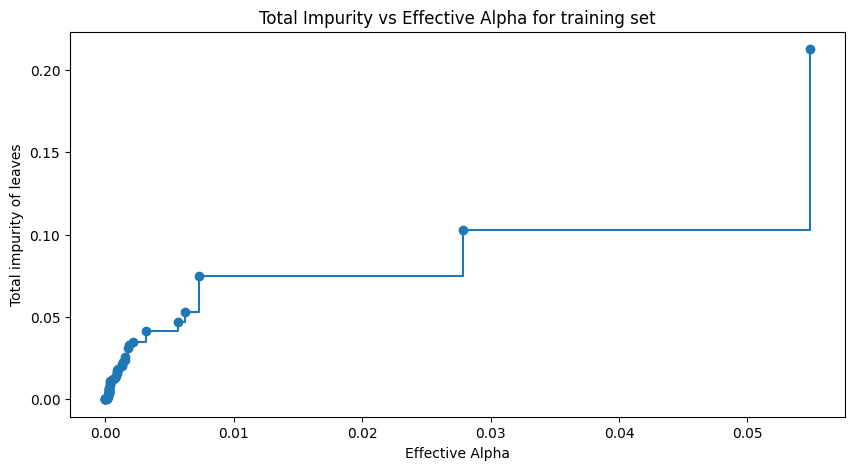

In [ ]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("Effective Alpha")

# Set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs Effective Alpha for training set");

- Train a decision tree using the effective alphas.

- The last value in `ccp_alphas` is the alpha value that prunes the whole tree,
leaving the corresponding tree with one node.

In [ ]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42, class_weight='balanced')

    # Fit the classifier to the training data
    clf.fit(X_train, y_train)

    # Append the trained classifier to the list
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.2874869303293992


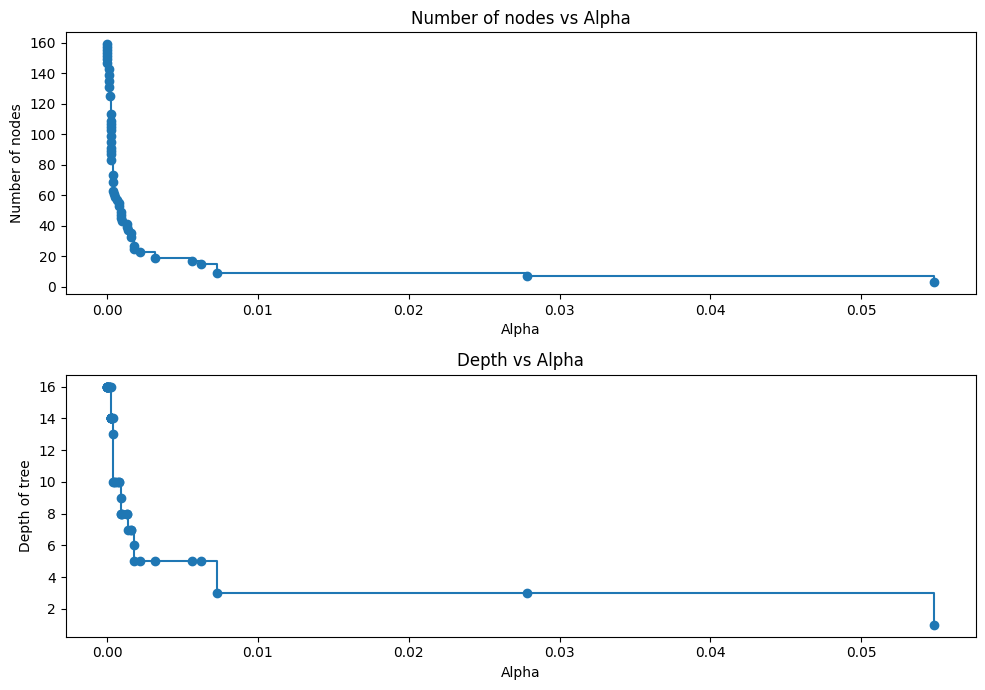

In [ ]:
# Remove the last element in clfs and ccp_alphas as it corresponds to a trivial tree with only one node
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract the number of nodes in each tree classifier
node_counts = [clf.tree_.node_count for clf in clfs]

# Extract the maximum depth of each tree classifier
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Number of nodes")
ax[0].set_title("Number of nodes vs Alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of tree")
ax[1].set_title("Depth vs Alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

In [ ]:
# Get the list of recall scores for the various decision trees for training data
train_recall_scores = []  # Initialize an empty list to store F1 scores for training set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the training set using the current decision tree classifier
    pred_train = clf.predict(X_train)

    # Calculate the F1 score for the training set predictions compared to true labels
    recall_train = recall_score(y_train, pred_train)

    # Append the calculated F1 score to the train_f1_scores list
    train_recall_scores.append(recall_train)

In [ ]:
# Get the list of recall scores for the various decision trees for test data
test_recall_scores = []  # Initialize an empty list to store F1 scores for test set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the test set using the current decision tree classifier
    pred_test = clf.predict(X_test)

    # Calculate the F1 score for the test set predictions compared to true labels
    recall_test = recall_score(y_test, pred_test)

    # Append the calculated F1 score to the test_f1_scores list
    test_recall_scores.append(recall_test)


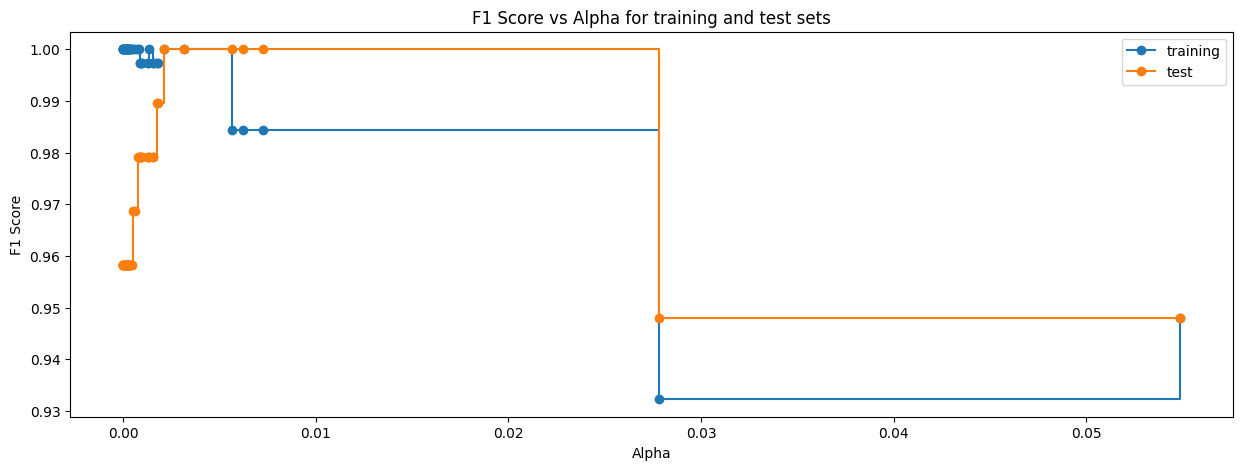

In [ ]:
# Create a plot plotting Alpha's against their recall scores
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")  # Set the label for the x-axis
ax.set_ylabel("F1 Score")  # Set the label for the y-axis
ax.set_title("F1 Score vs Alpha for training and test sets")  # Set the title of the plot

# Plot the training F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, train_recall_scores, marker="o", label="training", drawstyle="steps-post")

# Plot the testing F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, test_recall_scores, marker="o", label="test", drawstyle="steps-post")

ax.legend();  # Add a legend to the plot

In [ ]:
# creating the model where we get highest test Recall Score
index_best_model = np.argmax(test_recall_scores)

# selcting the decision tree model corresponding to the highest test score
model_postprune_best = clfs[index_best_model]
print(model_postprune_best)


DecisionTreeClassifier(ccp_alpha=np.float64(0.0021460800347084434),
                       class_weight='balanced', random_state=42)


#### Model Evaluation

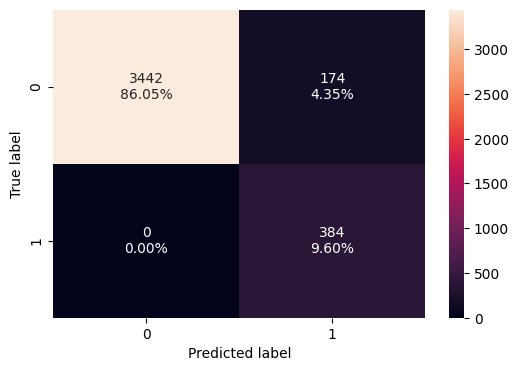

In [ ]:
confusion_matrix_sklearn(model_postprune_best, X_train, y_train)

In [ ]:
dtree_postprune_train_perf = model_performance_classification(
    model_postprune_best, X_train, y_train
)
dtree_postprune_train_perf

,Accuracy,Recall,Precision,F1
0,0.9565,1.0,0.688172,0.815287


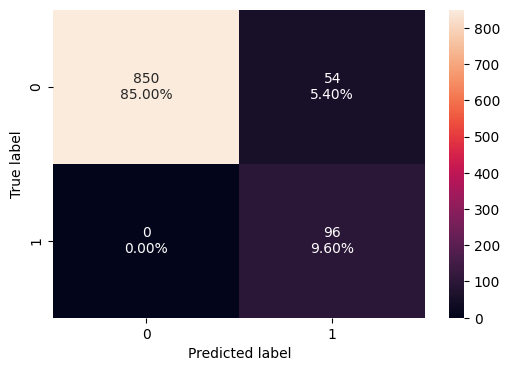

In [ ]:
confusion_matrix_sklearn(model_postprune_best, X_test, y_test)

In [ ]:
dtree_postprune_test_perf = model_performance_classification(
    model_postprune_best, X_test, y_test
)
dtree_postprune_test_perf

,Accuracy,Recall,Precision,F1
0,0.946,1.0,0.64,0.780488


#### Visualizing Decision Tree

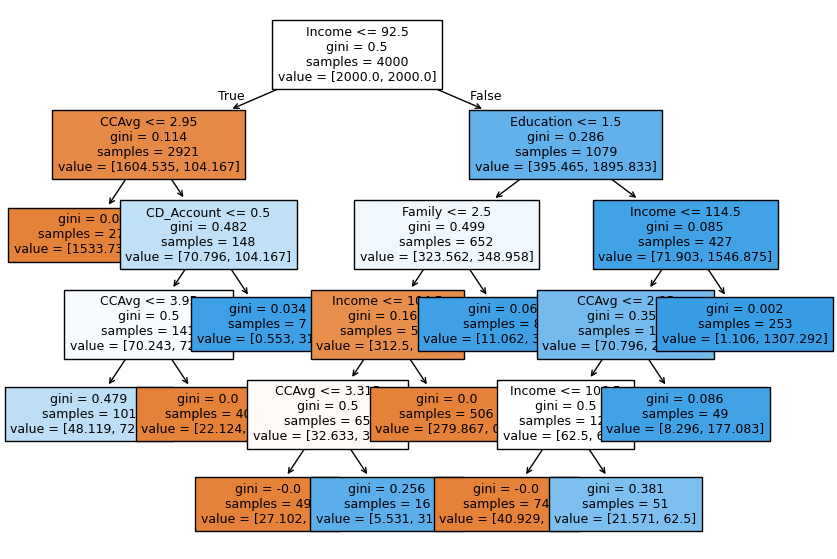

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(10, 7))

# plotting the decision tree
out = tree.plot_tree(
    model_postprune_best,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- *We can see that this model has more levels than the best prepruned model.*

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        model_postprune_best,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1533.74, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- weights: [48.12, 72.92] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- weights: [22.12, 0.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [0.55, 31.25] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 104.50
|   |   |   |   |--- CCAvg <= 3.31
|   |   |   |   |   |--- weights: [27.10, 0.00] class: 0
|   |   |   |   |--- CCAvg >  3.31
|   |   |   |   |   |--- weights: [5.53, 31.25] class: 1
|   |   |   |--- Income >  104.50
|   |   |   |   |--- weights: [279.87, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [11.06, 317.71] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 114.50
|   |   |   |--- CCAvg <= 2.95
|   |   |   |   |--- Income <= 106.50
|   |   |   |   |

- *This model has more rules than the best pre pruned model.*

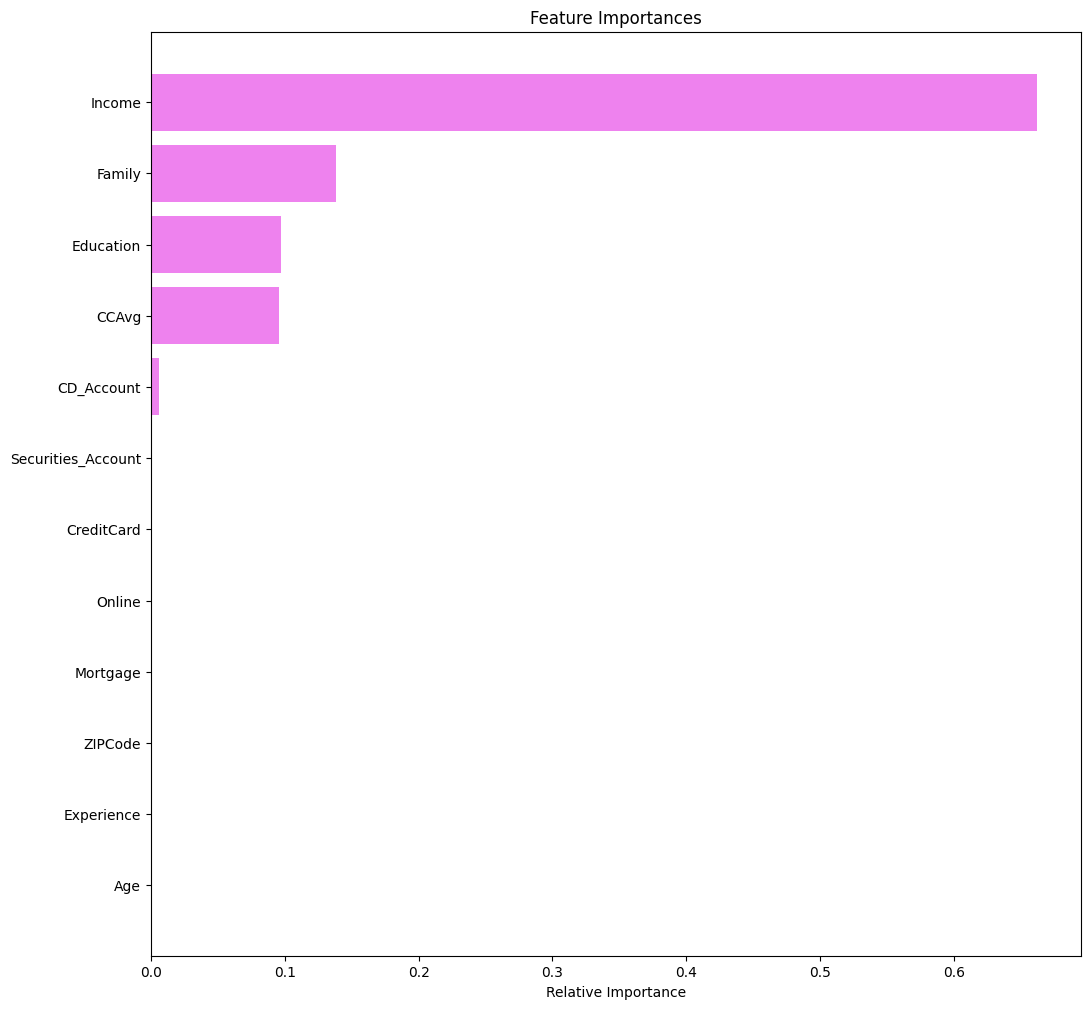

In [ ]:
# Create a plot showing the relative importance of the features in the decision tree
importances = model_postprune_best.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- *This model has 5 important features which is more than the best pre pruned model.*

## Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree_default_train_perf.T,
        dtree_preprune_train_perf.T,
        dtree_postprune_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.789250,0.956500
Recall,1.0,1.000000,1.000000
Precision,1.0,0.312958,0.688172
F1,1.0,0.476723,0.815287


In [ ]:
# Test performance comparison
models_test_comp_df = pd.concat(
    [
        dtree_default_test_perf.T,
        dtree_preprune_test_perf.T,
        dtree_postprune_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.980000,0.778000,0.946000
Recall,0.927083,1.000000,1.000000
Precision,0.872549,0.301887,0.640000
F1,0.898990,0.463768,0.780488


- Both the pre-pruned and post-pruned decision trees exhibit the maximum recall score of 1 on both the train and test sets.

- The best pre-pruned decision tree has lower scores on F1, precision and accuracy metrics on both test and training data compared to the post-tuned model.
    - This model uses only three features for decision-making.
    - This will result in a low prediction time but it might not be able to perform well on edge cases in unseen data.

- The best post-pruned decision tree has better performance metrics on F1, precision and accuracy metrics on both test and training data compared to the pre-tuned model.
    - This model uses five features for decision-making.
    - The model has more levels.
    - This will result in a slightly longer prediction time but it is likely to yield better results on unseen data as the metrics show.

- We'll move ahead with the post-pruned decision tree as our final model.

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

### Recommendations:

- *AllLife Bank should use this model for screening its customers to target potential loan buyers.*
- *Another option the bank could use it to change the model to predict probablility of the customer buying the loan using the predict_proba method of the DecisionTreeClassifier. The bank could target customers whose probability of buying the loan is greater than 80%.*
- *AllLife Bank should target customers with high Income for their personal loan campaign.*
- *They should also target customers with high Education for their personal loan campaign.*
- *The bank could target customers from certain zipcodes where more customers have bought the loans.*
- *They should also target customers between ages of 30 and 60 which is the age group which has bought the most personal loans.*
- *Since we saw that almost half of users who had a CD Account bought a personal loan, these users should also be targeted for personal loans.*
- *Customers with a family size of 3 and 4 could be targeted as they bought more loans compared to customers with lower family sizes.*

___